# Behavioral Narrative Figures for CORE-Bench v1.1 Decoupling Analysis

In [ ]:
%matplotlib inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import defaultdict, Counter
from pathlib import Path

# ---------- Output directory ----------
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# ---------- Style ----------
sns.set_theme(context="paper", style="white", font="Times New Roman")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi": 150,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

SCAFFOLD_COLORS = {
    "Codex CLI": "#0173b2",
    "Claude Code": "#de8f05",
    "OpenCode": "#029e73",
    "CORE-Agent": "#cc78bc",
}

PALETTE = {
    **SCAFFOLD_COLORS,
    "Open Code": SCAFFOLD_COLORS["OpenCode"],
    "Core Agent": SCAFFOLD_COLORS["CORE-Agent"],
    "CORE-Agent": SCAFFOLD_COLORS["CORE-Agent"],
}

MODEL_DISPLAY = {
    "claude-opus-4-5": "Opus 4.5",
    "claude-opus-4-6": "Opus 4.6",
    "gpt-5.4": "GPT-5.4",
}

def get_family(scaffold):
    if scaffold.startswith("Claude Code"):
        return "Claude Code"
    elif scaffold.startswith("Open Code"):
        return "Open Code"
    elif scaffold.startswith("Codex Agent"):
        return "Codex CLI"
    elif scaffold.startswith("Core Agent"):
        return "CORE-Agent"
    return "Other"


In [ ]:
# ---------- Load data ----------
with open("data/raw_focus.json") as f:
    data = json.load(f)

# load ground truth
with open("../core_test_final.json") as f:
    test_data = json.load(f)
gt_by_capsule = {c["capsule_id"]: c["results"] for c in test_data}

records = []
for item in data:
    meta = item["agent_run_metadata"]
    fa = str(meta.get("final_answer", ""))
    acc = meta["scores"].get("accuracy", 0)

    if acc == 1.0:
        failure_type = "pass"
    elif "timed out" in fa:
        failure_type = "timeout"
    elif "not produced" in fa:
        failure_type = "no_answer"
    elif fa and fa != "None" and not fa.startswith("ERROR"):
        failure_type = "wrong_answer"
    else:
        failure_type = "other_error"

    records.append({
        "scaffold": meta["scaffold"],
        "family": get_family(meta["scaffold"]),
        "model": meta.get("model", ""),
        "reasoning_effort": meta.get("reasoning_effort"),
        "capsule_id": meta["capsule_id"],
        "accuracy": acc,
        "failure_type": failure_type,
        "msg_count": len(item["messages"]),
        "final_answer": meta.get("final_answer"),
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} runs across {df['family'].nunique()} scaffold families, {df['model'].nunique()} models")
df.head(10)

Loaded 390 runs across 4 scaffold families, 3 models


,scaffold,family,model,reasoning_effort,capsule_id,accuracy,failure_type,msg_count,final_answer
0,"Claude Code (anthropic/claude-opus-4-5, think=...",Claude Code,claude-opus-4-5,"max 10,000",capsule-0201673,1.0,pass,53,"{'What is the p50?': 0.9999966483532146, 'What..."
1,"Claude Code (anthropic/claude-opus-4-5, think=...",Claude Code,claude-opus-4-5,"max 10,000",capsule-7800694,1.0,pass,51,{'Which model has the highest Macro F1?': 'Cat...
2,"Open Code (openai/gpt-5.4, re=high)",Open Code,gpt-5.4,high,capsule-8807709,1.0,pass,67,{'fig Report the name of the first subplot in ...
3,Claude Code (anthropic/claude-opus-4-6),Claude Code,claude-opus-4-6,adaptive,capsule-9054015,1.0,pass,53,{'fig Report the percentage sensitivity for ca...
4,Claude Code (anthropic/claude-opus-4-6),Claude Code,claude-opus-4-6,adaptive,capsule-9240688,1.0,pass,45,"{'From table 1, report the portion relevant in..."
5,"Core Agent (anthropic/claude-opus-4-5, steps=200)",CORE-Agent,claude-opus-4-5,NaN,capsule-4933686,1.0,pass,60,"{'fig From Figure 2 plot A, report Fisher's P...."
6,"Core Agent (anthropic/claude-opus-4-5, steps=200)",CORE-Agent,claude-opus-4-5,NaN,capsule-7655932,1.0,pass,46,{'What is the point estimate (deaths averted s...
7,"Core Agent (anthropic/claude-opus-4-6, steps=200)",CORE-Agent,claude-opus-4-6,NaN,capsule-2242462,1.0,pass,54,{'What is the Chromosome chr1 with positioning...
8,"Core Agent (anthropic/claude-opus-4-6, steps=200)",CORE-Agent,claude-opus-4-6,NaN,capsule-9477017,1.0,pass,94,{'fig Pearson correlation coefficients between...
9,"Core Agent (gpt-5.4, steps=200)",CORE-Agent,gpt-5.4,medium,capsule-3821950,0.0,wrong_answer,30,{'fig Report the name of the material with the...


In [ ]:
df.columns

Index(['scaffold', 'family', 'model', 'reasoning_effort', 'capsule_id',
       'accuracy', 'failure_type', 'msg_count', 'final_answer'],
      dtype='str')

## Scaffold Accuracy Spread by Model 

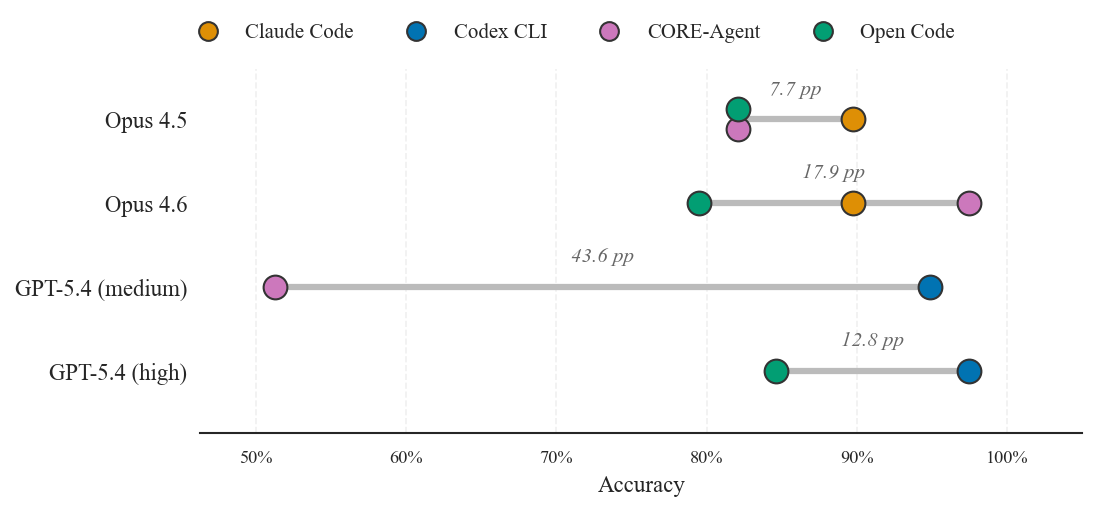

In [ ]:
df_plot = df.copy()
df_plot["model_panel"] = df_plot.apply(
    lambda r: f"gpt-5.4::{r['reasoning_effort']}" if r["model"] == "gpt-5.4" else r["model"],
    axis=1,
)
multi = df_plot.groupby("model_panel")["family"].nunique()
multi = multi[multi >= 2].index.tolist()

cell_acc = (df_plot[df_plot["model_panel"].isin(multi)].groupby(["model_panel", "family"])["accuracy"].mean().reset_index())

model_order = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4::medium", "gpt-5.4::high"]
models = [m for m in model_order if m in multi] + [m for m in multi if m not in model_order]

def panel_label(p):
    if "::" in p:
        return f"GPT-5.4 ({p.split('::')[1]})"
    return MODEL_DISPLAY.get(p, p)

fig, ax = plt.subplots(figsize=(7.2, 3.3), constrained_layout=True)
for i, model in enumerate(models):
    mdf = cell_acc[cell_acc["model_panel"] == model]
    lo, hi = mdf["accuracy"].min(), mdf["accuracy"].max()

    ax.plot([lo, hi], [i, i], color="#bbbbbb", linewidth=3, zorder=1, solid_capstyle="round")
    ax.text((lo + hi) / 2, i - 0.25, f"{(hi - lo) * 100:.1f} pp",
            ha="center", va="bottom", fontsize=10, color="#666", fontstyle="italic")

    for _, row in mdf.iterrows():
        y_offset = i

        if model == "claude-opus-4-5" and row["family"] == "Open Code":
            y_offset = i - 0.12
        elif model == "claude-opus-4-5" and row["family"] == "CORE-Agent":
            y_offset = i + 0.12

        ax.scatter(row["accuracy"], y_offset,
                   color=PALETTE.get(row["family"], "#999"), s=130, zorder=3,
                   edgecolors="#333", linewidths=1.0)

ax.set_yticks(range(len(models)))
ax.set_yticklabels([panel_label(m) for m in models], fontsize=11)
ax.invert_yaxis()
ax.set_ylim(len(models) - 0.25, -0.6)

ax.set_xlabel("Accuracy", fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlim(max(0.4, cell_acc["accuracy"].min() - 0.05), 1.05)

ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, pad=6)

used = cell_acc["family"].unique()
legend_scaffolds = [s for s in ["Claude Code", "Codex CLI", "CORE-Agent", "Open Code"] if s in used]
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[s],
               markersize=9, markeredgecolor="#333", markeredgewidth=1.0, label=s)
    for s in legend_scaffolds
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.42, 1.02),
          ncol=len(legend_scaffolds), frameon=False, fontsize=10)

fig.savefig(FIG_DIR / "scaffold_accuracy_spread_by_model_setting.png")
plt.show()

## Same-Scaffold Model Sensitivity Grid

Wrote 250 plotted cells to CSV
outcome                            fail  pass
scaffold_family model_panel_label            
CORE-Agent      GPT-5.4 (medium)     19     6
                Opus 4.5              7    18
                Opus 4.6              1    24
Claude Code     Opus 4.5              4    21
                Opus 4.6              4    21
Codex CLI       GPT-5.4 (high)        1    24
                GPT-5.4 (medium)      2    23
Open Code       GPT-5.4 (high)        6    19
                Opus 4.5              7    18
                Opus 4.6              8    17


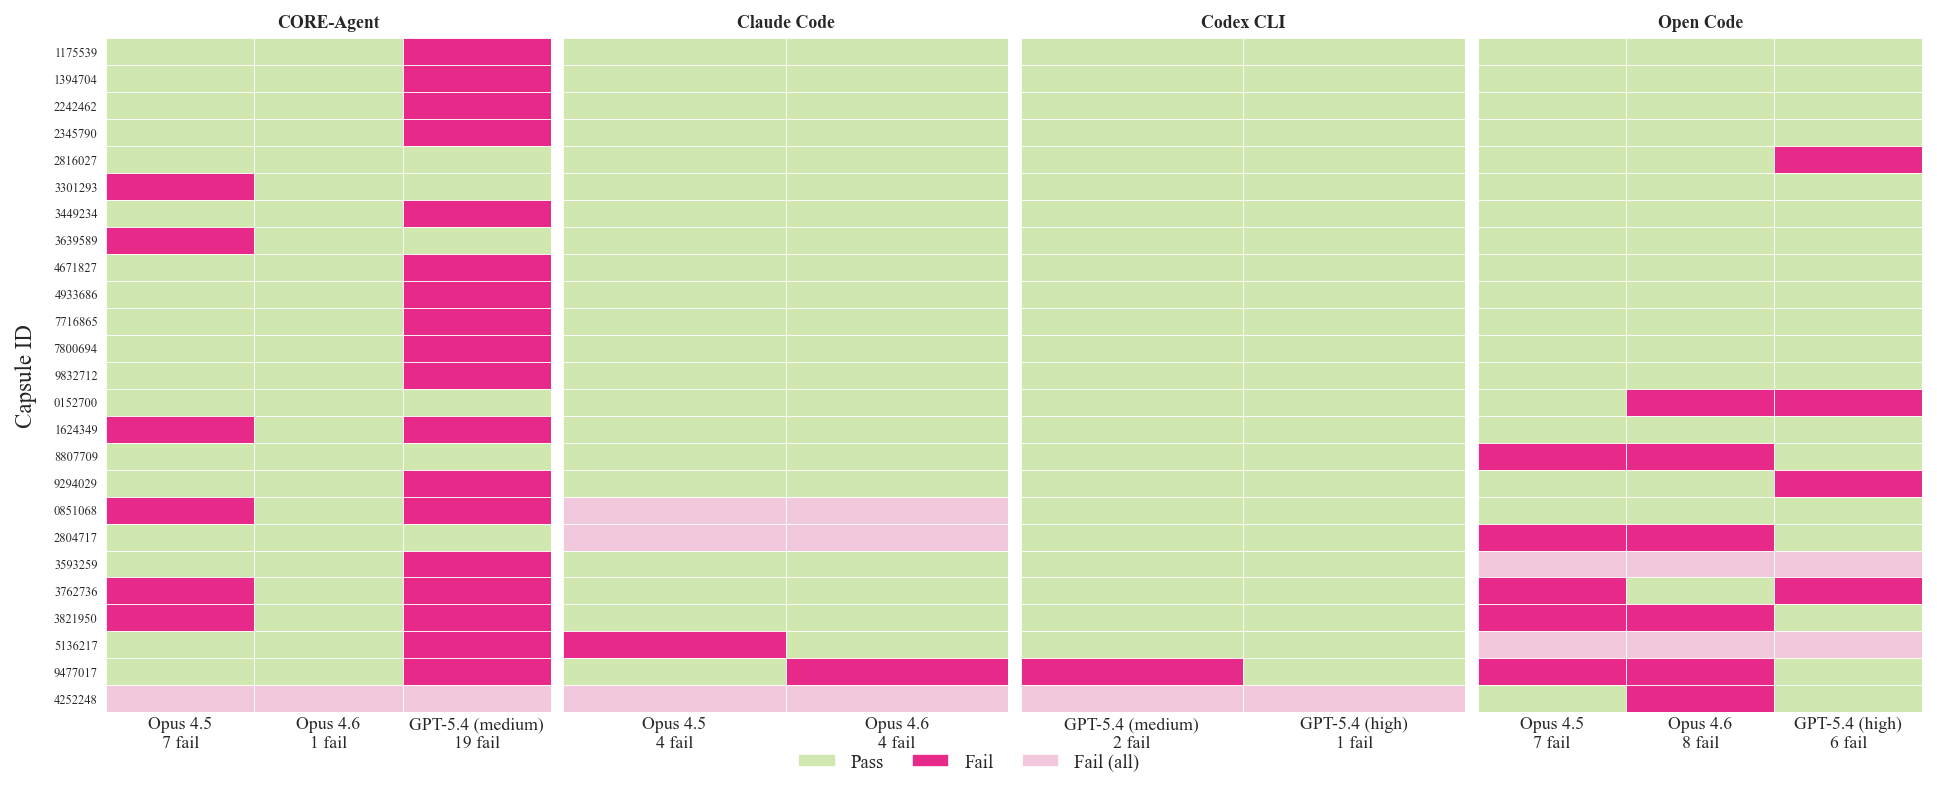

In [ ]:
PASS_COLOR = "#d0e8b0"
FAIL_COLOR = "#e7298a"
PASS_MUTED = "#d0e8b0"
FAIL_MUTED = "#f2c9dc"

def _model_panel_label(p):
    if "::" in p:
        return f"GPT-5.4 ({p.split('::')[1]})"
    return MODEL_DISPLAY.get(p, p)

# Build model_panel column
df_mp = df.copy()
df_mp["model_panel"] = df_mp.apply(
    lambda r: f"gpt-5.4::{r['reasoning_effort']}" if r["model"] == "gpt-5.4" else r["model"],
    axis=1,
)

model_order = ["claude-opus-4-5", "claude-opus-4-6", "gpt-5.4::medium", "gpt-5.4::high"]

# Scaffolds with 2+ model panels
multi_scaffolds = (
    df_mp.groupby("family")["model_panel"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index.tolist()
)

# Shared capsule order: keep only capsules with at least one fail
flip_any = {}
fail_any = {}
pass_total = {}

for scaffold in multi_scaffolds:
    sdf = df_mp[df_mp["family"] == scaffold]
    models = [m for m in model_order if m in set(sdf["model_panel"])]

    piv = sdf.pivot_table(
        index="capsule_id", columns="model_panel", values="accuracy", aggfunc="mean",
    )[models]

    for cap in piv.index:
        row = piv.loc[cap].dropna()
        flipped = row.nunique() > 1
        has_fail = (row < 0.5).any()

        flip_any[cap] = flip_any.get(cap, False) or flipped
        fail_any[cap] = fail_any.get(cap, False) or has_fail
        pass_total[cap] = pass_total.get(cap, 0) + row.sum()

sort_df = pd.DataFrame({
    "flip": pd.Series(flip_any).astype(int),
    "fail": pd.Series(fail_any).astype(int),
    "passes": pd.Series(pass_total),
})

shared_order = (
    sort_df.query("fail == 1")
    .sort_values(["flip", "passes"], ascending=[False, False])
    .index.tolist()
)
n_caps = len(shared_order)

fig, axes = plt.subplots(
    1, len(multi_scaffolds),
    figsize=(3.2 * len(multi_scaffolds), max(5.0, 0.16 * n_caps)),
    sharey=True, constrained_layout=True,
)
if len(multi_scaffolds) == 1:
    axes = [axes]

csv_rows = []

for ax_idx, (ax, scaffold) in enumerate(zip(axes, multi_scaffolds)):
    sdf = df_mp[df_mp["family"] == scaffold]
    models = [m for m in model_order if m in set(sdf["model_panel"])]

    piv_all = sdf.pivot_table(
        index="capsule_id", columns="model_panel", values="accuracy", aggfunc="mean",
    )[models]

    changed_all = piv_all.apply(lambda r: r.dropna().nunique() > 1, axis=1)
    piv = piv_all.reindex(shared_order)

    for i, cap in enumerate(shared_order):
        is_changed = bool(changed_all.loc[cap])

        for j, mp in enumerate(models):
            val = piv.loc[cap, mp]

            if pd.isna(val):
                color = "#f0f0f0"
                outcome = "missing"
            elif val >= 0.5:
                color = PASS_COLOR if is_changed else PASS_MUTED
                outcome = "pass"
            else:
                color = FAIL_COLOR if is_changed else FAIL_MUTED
                outcome = "fail"

            rect = mpatches.Rectangle(
                (j, n_caps - 1 - i), 1, 1,
                facecolor=color, edgecolor="white", linewidth=0.4,
            )
            ax.add_patch(rect)

            csv_rows.append({
                "scaffold_family": scaffold,
                "model_panel": mp,
                "model_panel_label": _model_panel_label(mp),
                "capsule_id": cap,
                "accuracy": val,
                "outcome": outcome,
                "model_sensitive_in_scaffold": is_changed,
                "color": color,
            })

    col_labels = []
    for mp in models:
        col = piv_all[mp].dropna()
        n_fail = int((col < 0.5).sum())
        col_labels.append(f"{_model_panel_label(mp)}\n{n_fail} fail")

    ax.set_xticks([j + 0.5 for j in range(len(models))])
    ax.set_xticklabels(col_labels, fontsize=8.5, ha="center", linespacing=1.3)
    ax.set_xlim(0, len(models))
    ax.set_ylim(0, n_caps)

    if ax_idx == 0:
        ax.set_yticks([n_caps - 1 - i + 0.5 for i in range(n_caps)])
        ax.set_yticklabels(
            [str(c).replace("capsule-", "") for c in shared_order],
            fontsize=6, fontfamily="Times New Roman",
        )
        ax.tick_params(axis="y", length=0, pad=4)
        ax.set_ylabel("Capsule ID", fontsize=11, labelpad=8)
    else:
        ax.tick_params(axis="y", labelleft=False, length=0)

    ax.text(0.5, 1.01, scaffold, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", length=0, pad=2)

handles = [
    mpatches.Patch(facecolor=PASS_COLOR, edgecolor="white", label="Pass"),
    mpatches.Patch(facecolor=FAIL_COLOR, edgecolor="white", label="Fail"),
    mpatches.Patch(facecolor=FAIL_MUTED, edgecolor="white", label="Fail (all)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), columnspacing=1.5)

model_sens_csv = pd.DataFrame(csv_rows)
model_sens_csv.to_csv("same_scaffold_model_outcomes_with_fails_cells.csv", index=False)

print(f"Wrote {len(model_sens_csv)} plotted cells to CSV")
print(model_sens_csv.groupby(["scaffold_family", "model_panel_label", "outcome"]).size().unstack(fill_value=0))

fig.savefig(FIG_DIR / "same_scaffold_model_outcomes_with_fails.pdf")
fig.savefig(FIG_DIR / "same_scaffold_model_outcomes_with_fails.png")
plt.show()

## Failure-Mode Stacked Bar

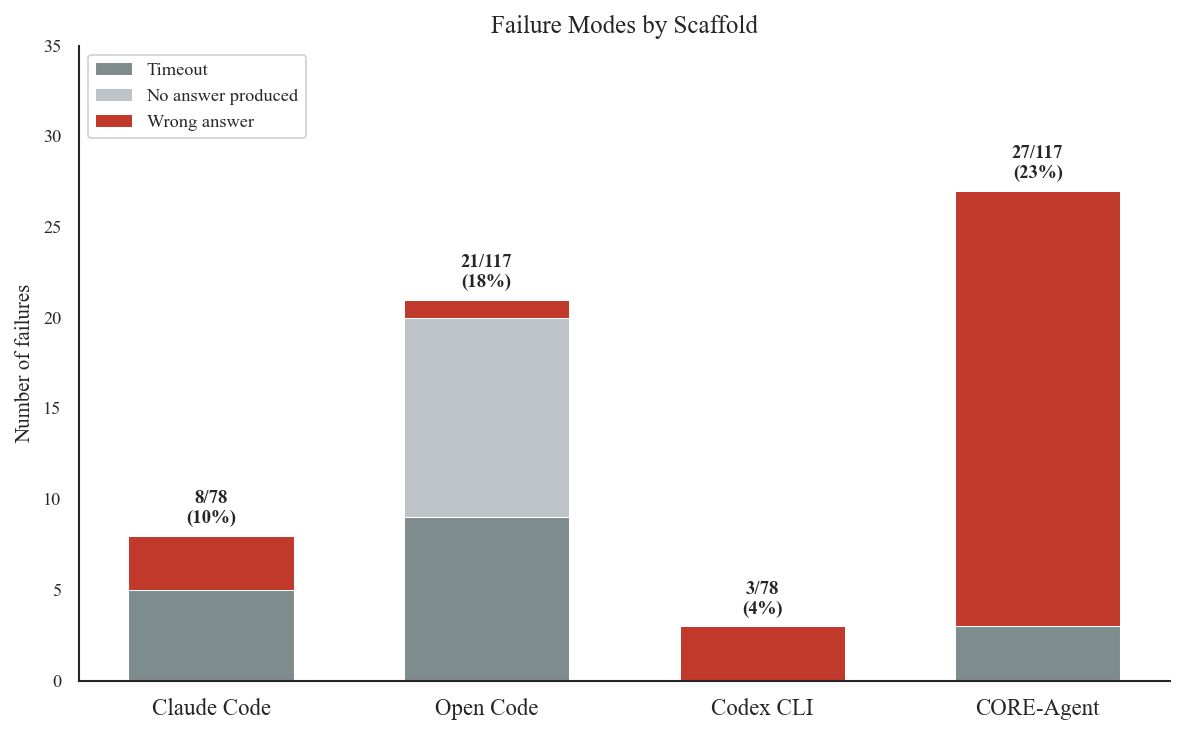

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]
failure_types = ["timeout", "no_answer", "wrong_answer"]
colors = {"timeout": "#7f8c8d", "no_answer": "#bdc3c7", "wrong_answer": "#c0392b"}
labels = {"timeout": "Timeout", "no_answer": "No answer produced", "wrong_answer": "Wrong answer"}

fails_only = df[df["failure_type"] != "pass"]

counts = {}
for fam in families:
    fam_fails = fails_only[fails_only["family"] == fam]
    counts[fam] = {ft: len(fam_fails[fam_fails["failure_type"] == ft]) for ft in failure_types}

x = np.arange(len(families))
width = 0.6
bottoms = np.zeros(len(families))

for ft in failure_types:
    vals = [counts[fam][ft] for fam in families]
    ax.bar(x, vals, width, bottom=bottoms, color=colors[ft], label=labels[ft], edgecolor="white", linewidth=0.5)
    bottoms += vals

for i, fam in enumerate(families):
    total = sum(counts[fam].values())
    total_runs = len(df[df["family"] == fam])
    ax.text(i, bottoms[i] + 0.5, f"{total}/{total_runs}\n({100*total/total_runs:.0f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=11)
ax.set_ylabel("Number of failures")
ax.set_title("Failure Modes by Scaffold")
ax.legend(loc="upper left", framealpha=0.9)
ax.set_ylim(0, max(bottoms) + 8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_failure_modes_stacked.png")
fig.savefig(FIG_DIR / "behavioral_failure_modes_stacked.pdf")
plt.show()

## Message Count — Pass vs Fail (Spiral vs Surrender)

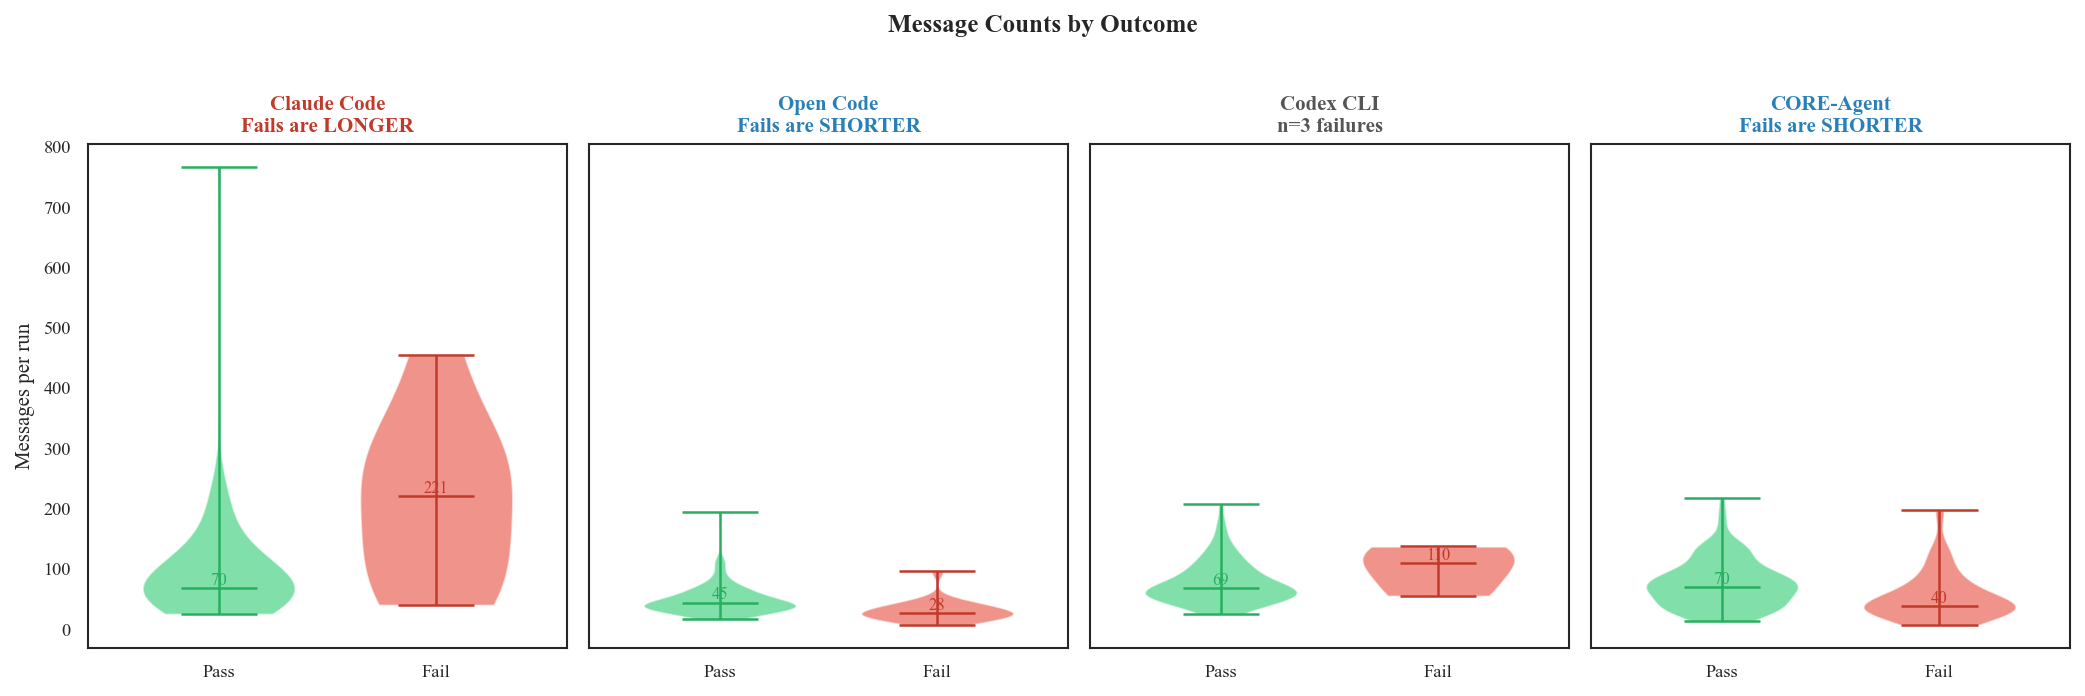

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharey=True)

families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]

for ax, fam in zip(axes, families):
    fam_df = df[df["family"] == fam]
    pass_msgs = fam_df[fam_df["accuracy"] == 1.0]["msg_count"]
    fail_msgs = fam_df[fam_df["accuracy"] == 0.0]["msg_count"]

    parts_pass = ax.violinplot([pass_msgs.values], positions=[0], showmedians=True, widths=0.7)
    parts_fail = ax.violinplot([fail_msgs.values] if len(fail_msgs) > 0 else [[0]], positions=[1], showmedians=True, widths=0.7)

    for pc in parts_pass["bodies"]:
        pc.set_facecolor("#2ecc71")
        pc.set_alpha(0.6)
    for key in ["cmins", "cmaxes", "cbars", "cmedians"]:
        if key in parts_pass:
            parts_pass[key].set_color("#27ae60")

    for pc in parts_fail["bodies"]:
        pc.set_facecolor("#e74c3c")
        pc.set_alpha(0.6)
    for key in ["cmins", "cmaxes", "cbars", "cmedians"]:
        if key in parts_fail:
            parts_fail[key].set_color("#c0392b")

    pass_med = pass_msgs.median()
    fail_med = fail_msgs.median() if len(fail_msgs) > 0 else 0

    if len(fail_msgs) >= 5:
        direction = "LONGER" if fail_med > pass_med else "SHORTER"
        color = "#c0392b" if fail_med > pass_med else "#2980b9"
        subtitle = f"Fails are {direction}"
    else:
        color = "#555555"
        subtitle = f"n={len(fail_msgs)} failures"

    ax.set_title(f"{fam}\n{subtitle}", fontsize=10, color=color, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pass", "Fail"])
    ax.set_xlim(-0.6, 1.6)

    ax.text(0, pass_med + 5, f"{pass_med:.0f}", ha="center", fontsize=8, color="#27ae60")
    if len(fail_msgs) > 0:
        ax.text(1, fail_med + 5, f"{fail_med:.0f}", ha="center", fontsize=8, color="#c0392b")

axes[0].set_ylabel("Messages per run")
fig.suptitle("Message Counts by Outcome", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_spiral_vs_surrender.png")
fig.savefig(FIG_DIR / "behavioral_spiral_vs_surrender.pdf")
plt.show()

## Capsule x Scaffold Heatmap (Behavioral)

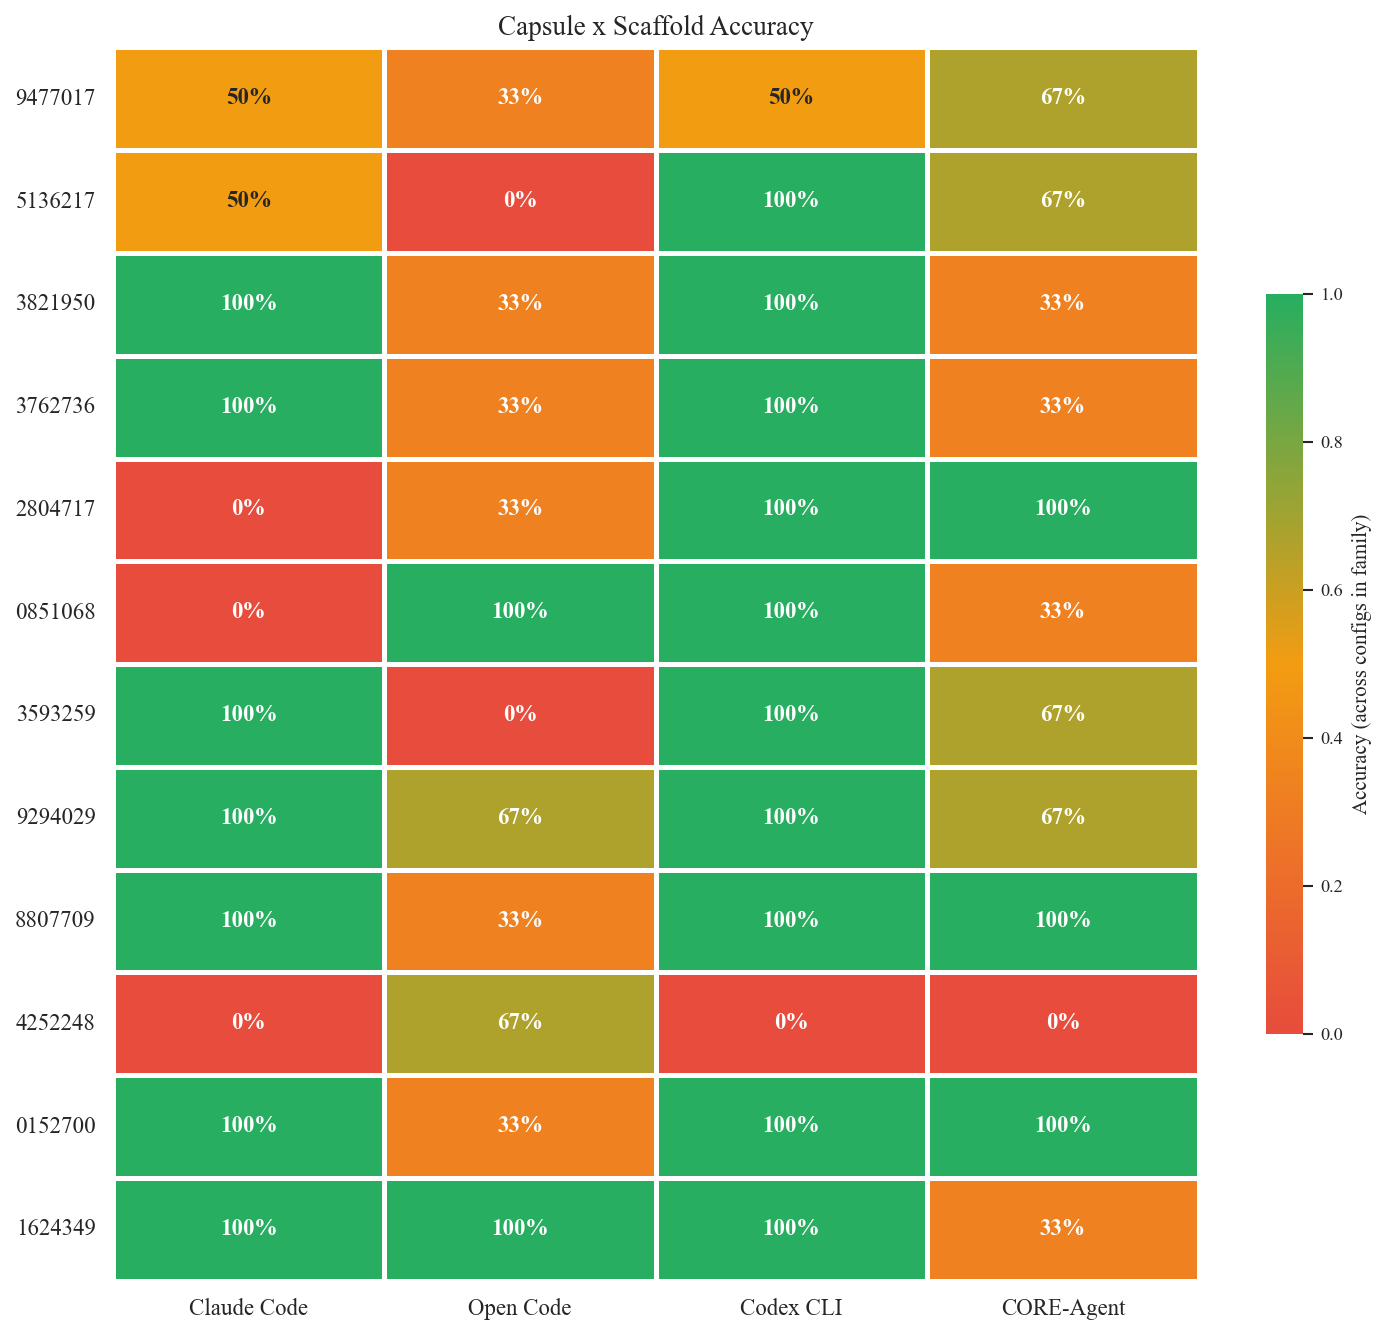

In [ ]:
capsule_var = df.groupby("capsule_id")["accuracy"].var().sort_values(ascending=False)
top_capsules = capsule_var.head(12).index.tolist()

families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]
matrix_data = []
for capsule in top_capsules:
    row = {}
    for fam in families:
        fam_runs = df[(df["capsule_id"] == capsule) & (df["family"] == fam)]
        if len(fam_runs) > 0:
            row[fam] = fam_runs["accuracy"].mean()
        else:
            row[fam] = np.nan
    matrix_data.append(row)

matrix_df = pd.DataFrame(matrix_data, index=top_capsules)

fig, ax = plt.subplots(figsize=(10, 9))

cmap = LinearSegmentedColormap.from_list("rg", ["#e74c3c", "#f39c12", "#27ae60"])

sns.heatmap(matrix_df, ax=ax, cmap=cmap, vmin=0, vmax=1,
            annot=True, fmt=".0%", linewidths=1.5, linecolor="white",
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            cbar_kws={"label": "Accuracy (across configs in family)", "shrink": 0.6})

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Capsule x Scaffold Accuracy", fontsize=13)

ylabels = [c.replace("capsule-", "") for c in top_capsules]
ax.set_yticklabels(ylabels, rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_capsule_heatmap.png")
fig.savefig(FIG_DIR / "behavioral_capsule_heatmap.pdf")
plt.show()

## Precision Funnel (capsule-4252248)

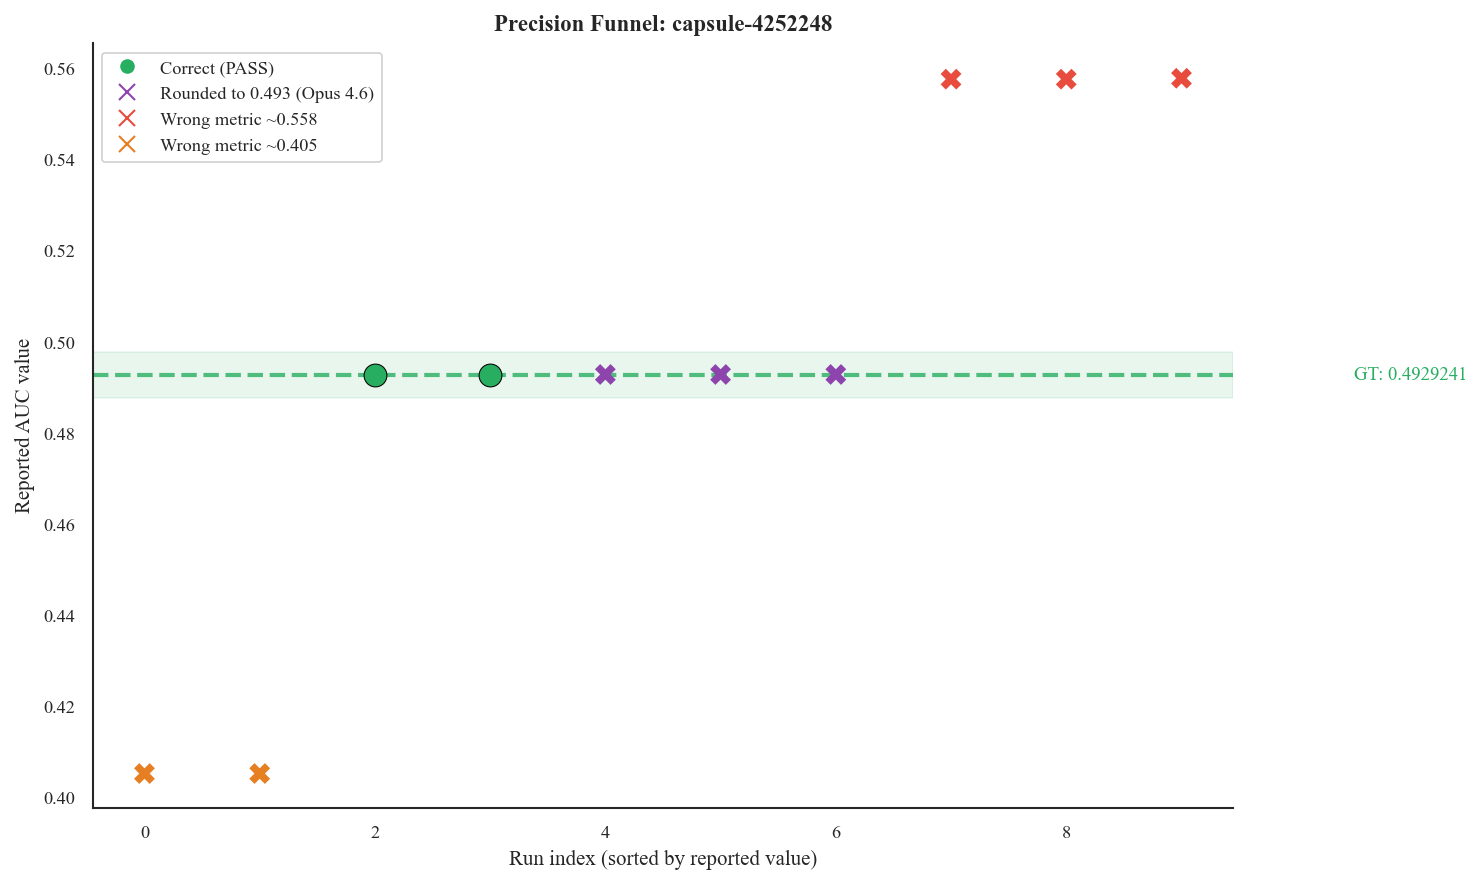

In [ ]:
target = "capsule-4252248"
gt_val = 0.4929241

values = []
for item in data:
    meta = item["agent_run_metadata"]
    if meta["capsule_id"] != target:
        continue
    fa = meta.get("final_answer", {})
    if isinstance(fa, dict) and fa:
        val = list(fa.values())[0]
        try:
            if isinstance(val, str) and "=" in val:
                val = None
            else:
                val = float(val)
        except (ValueError, TypeError):
            val = None
    else:
        val = None
    values.append({
        "scaffold": meta["scaffold"],
        "family": get_family(meta["scaffold"]),
        "value": val,
        "accuracy": meta["scores"].get("accuracy", 0),
    })

val_df = pd.DataFrame(values)
val_df = val_df.dropna(subset=["value"])

def classify_value(v):
    if abs(v - 0.493) < 0.0005 and abs(v - gt_val) > 0.00005:
        return "Rounded (0.493)"
    elif abs(v - gt_val) < 0.0001:
        return "Correct (approx 0.4929)"
    elif abs(v - 0.5578) < 0.01:
        return "Wrong metric A (approx 0.558)"
    elif abs(v - 0.405) < 0.01:
        return "Wrong metric B (approx 0.405)"
    else:
        return "Other wrong value"

val_df["cluster"] = val_df["value"].apply(classify_value)

cluster_colors = {
    "Correct (approx 0.4929)": "#27ae60",
    "Rounded (0.493)": "#8e44ad",
    "Wrong metric A (approx 0.558)": "#e74c3c",
    "Wrong metric B (approx 0.405)": "#e67e22",
    "Other wrong value": "#7f8c8d",
}

fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(gt_val, color="#27ae60", linewidth=2, linestyle="--", alpha=0.8, zorder=1)
ax.axhspan(gt_val - 0.005, gt_val + 0.005, alpha=0.1, color="#27ae60", zorder=0)
ax.text(len(val_df) + 0.5, gt_val, f"GT: {gt_val}", va="center", fontsize=9, color="#27ae60")

val_df = val_df.sort_values("value").reset_index(drop=True)

for i, row in val_df.iterrows():
    color = cluster_colors.get(row["cluster"], "#7f8c8d")
    marker = "o" if row["accuracy"] == 1.0 else "X"
    size = 120 if row["accuracy"] == 1.0 else 100
    ax.scatter(i, row["value"], c=color, marker=marker, s=size, zorder=3,
               edgecolors="black" if row["accuracy"] == 1.0 else "none", linewidths=0.5)

present_clusters = set(val_df["cluster"].values)
all_legend = [
    ("Correct (approx 0.4929)", Line2D([0], [0], marker="o", color="w", markerfacecolor="#27ae60", markersize=8, label="Correct (PASS)")),
    ("Rounded (0.493)", Line2D([0], [0], marker="x", color="#8e44ad", markersize=8, label="Rounded to 0.493 (Opus 4.6)", linestyle="None")),
    ("Wrong metric A (approx 0.558)", Line2D([0], [0], marker="x", color="#e74c3c", markersize=8, label="Wrong metric ~0.558", linestyle="None")),
    ("Wrong metric B (approx 0.405)", Line2D([0], [0], marker="x", color="#e67e22", markersize=8, label="Wrong metric ~0.405", linestyle="None")),
]
legend_elements = [el for key, el in all_legend if key in present_clusters]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.9)

ax.set_xlabel("Run index (sorted by reported value)")
ax.set_ylabel("Reported AUC value")
ax.set_title("Precision Funnel: capsule-4252248", fontsize=11, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_precision_funnel.png")
fig.savefig(FIG_DIR / "behavioral_precision_funnel.pdf")
plt.show()

## Scaffold Effect Butterfly (Opus 4.5 across scaffolds)

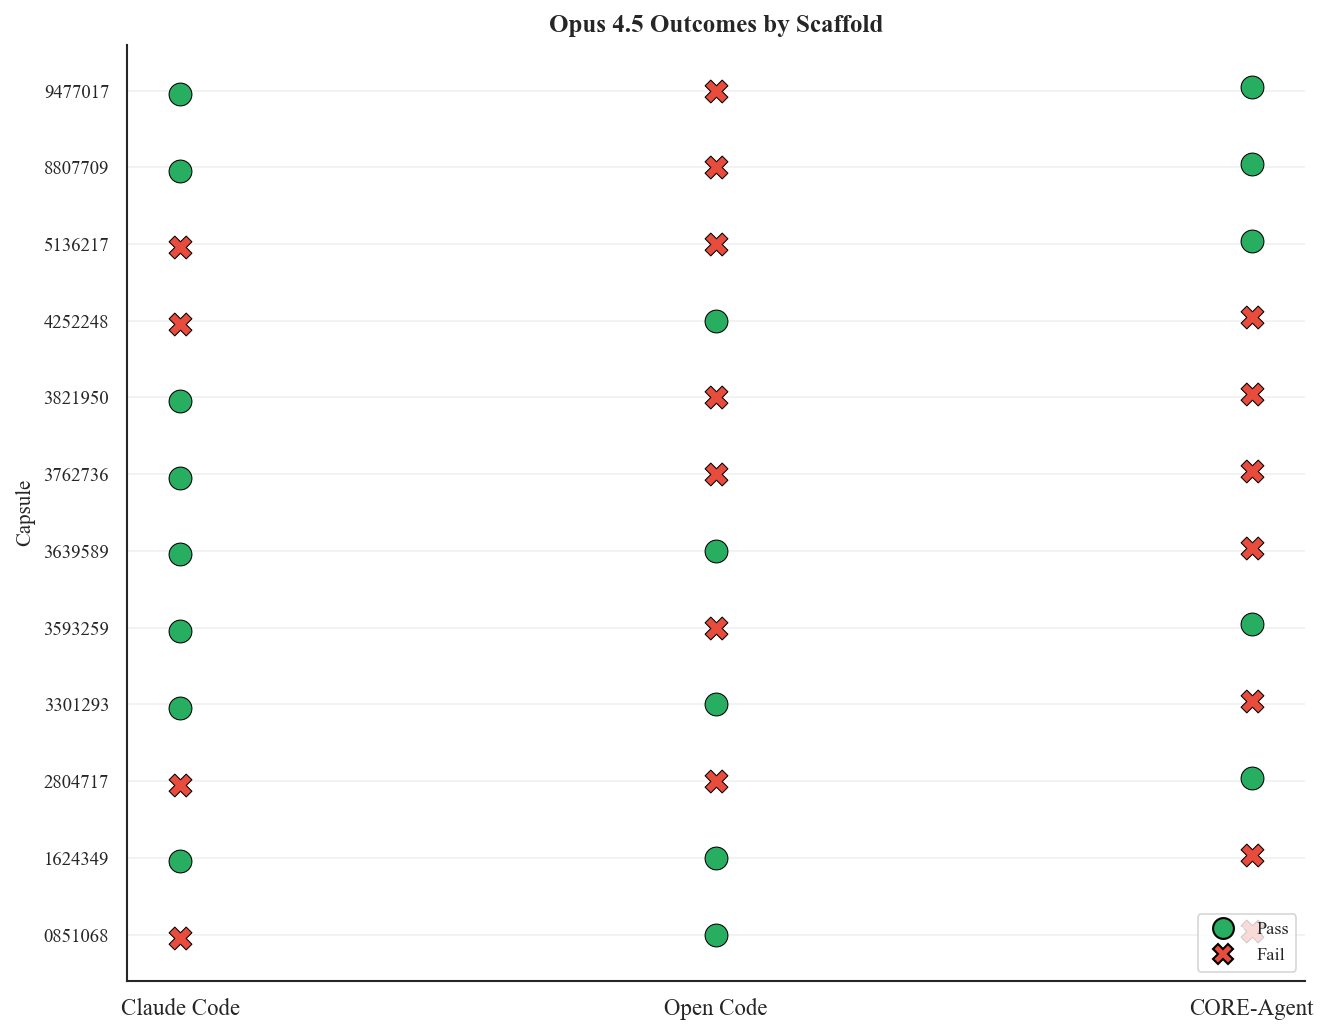

In [ ]:
opus45 = df[df["model"].str.contains("opus-4-5|opus_4_5", case=False, na=False)].copy()

opus45["scaffold_short"] = opus45["scaffold"].apply(
    lambda s: "Claude Code" if "Claude Code" in s else
              "Open Code" if "Open Code" in s else
              "CORE-Agent" if "Core Agent" in s else s[:20]
)

scaffolds = ["Claude Code", "Open Code", "CORE-Agent"]
opus45_filtered = opus45[opus45["scaffold_short"].isin(scaffolds)]

pivot = opus45_filtered.pivot_table(index="capsule_id", columns="scaffold_short",
                                     values="accuracy", aggfunc="first")

disagree = pivot[pivot.apply(lambda row: row.min() != row.max(), axis=1)]

fig, ax = plt.subplots(figsize=(9, 7))

capsules = disagree.index.tolist()
y_pos = np.arange(len(capsules))

for i, capsule in enumerate(capsules):
    for j, scaffold in enumerate(scaffolds):
        val = disagree.loc[capsule, scaffold] if scaffold in disagree.columns else np.nan
        if pd.isna(val):
            continue
        color = "#27ae60" if val == 1.0 else "#e74c3c"
        marker = "o" if val == 1.0 else "X"
        offset = (j - 1) * 0.15
        ax.scatter(j, i + offset * 0.3, c=color, marker=marker, s=120, zorder=3,
                   edgecolors="black", linewidths=0.5)

ax.set_xticks(range(len(scaffolds)))
ax.set_xticklabels(scaffolds, fontsize=11)
ax.set_yticks(y_pos)
ax.set_yticklabels([c.replace("capsule-", "") for c in capsules], fontsize=9)
ax.set_ylabel("Capsule")
ax.set_title("Opus 4.5 Outcomes by Scaffold", fontsize=12, fontweight="bold")

ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#27ae60", markersize=10, markeredgecolor="black", label="Pass"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="#e74c3c", markersize=10, markeredgecolor="black", label="Fail"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_butterfly_opus45.png")
fig.savefig(FIG_DIR / "behavioral_butterfly_opus45.pdf")
plt.show()

## Spider/Radar Plot — Scaffold Behavioral Profile

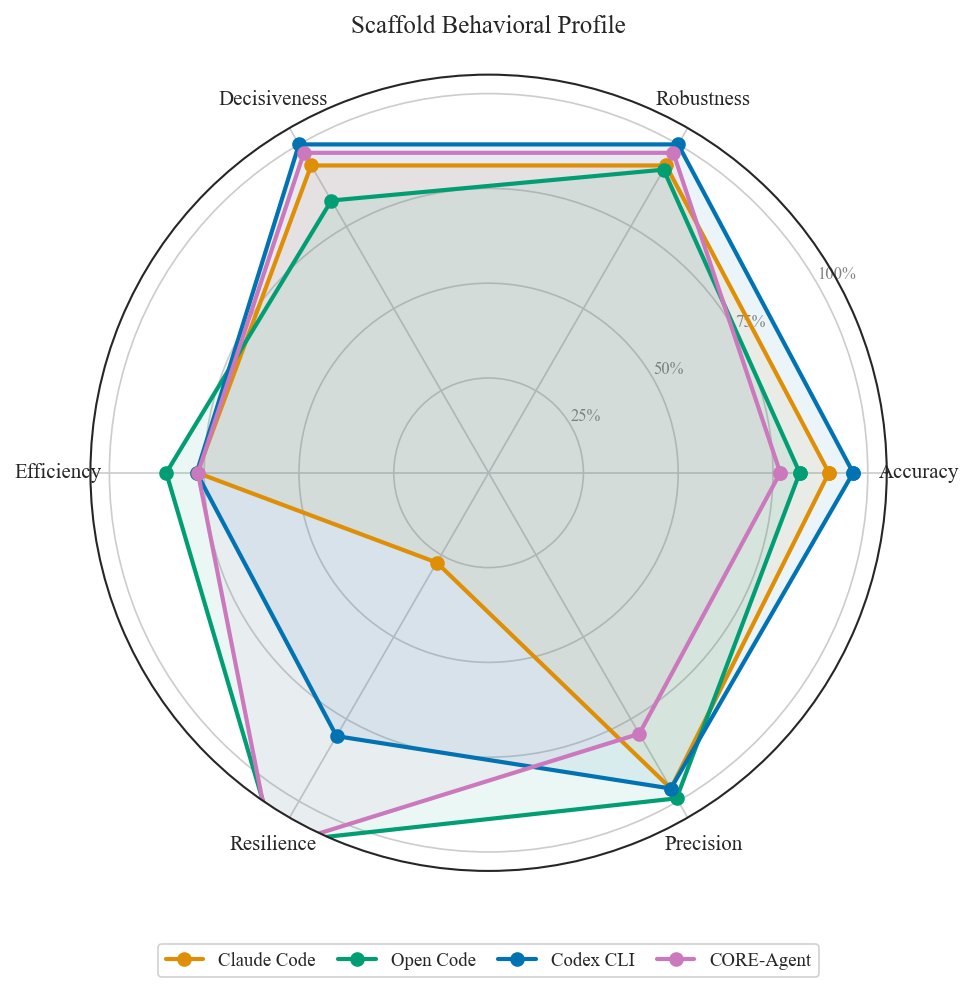

In [ ]:
families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]

metrics = {}
for fam in families:
    fam_df = df[df["family"] == fam]
    fam_pass = fam_df[fam_df["accuracy"] == 1.0]
    fam_fail = fam_df[fam_df["accuracy"] == 0.0]

    total = len(fam_df)
    n_fail = len(fam_fail)

    accuracy = fam_pass.shape[0] / total if total > 0 else 0
    timeouts = len(fam_fail[fam_fail["failure_type"] == "timeout"])
    robustness = 1 - (timeouts / total) if total > 0 else 1
    no_answers = len(fam_fail[fam_fail["failure_type"].isin(["timeout", "no_answer"])])
    decisiveness = 1 - (no_answers / total) if total > 0 else 1
    pass_median = fam_pass["msg_count"].median() if len(fam_pass) > 0 else 200
    efficiency = 1 - (pass_median / 300)
    pass_med = fam_pass["msg_count"].median() if len(fam_pass) > 0 else 50
    fail_med = fam_fail["msg_count"].median() if len(fam_fail) > 0 else 50
    ratio = fail_med / pass_med if pass_med > 0 else 1
    resilience = max(0, 1 - (ratio - 1) / 3)
    wrong_ans = fam_fail[fam_fail["failure_type"] == "wrong_answer"]
    precision = 1 - (len(wrong_ans) / total) if total > 0 else 1

    metrics[fam] = [accuracy, robustness, decisiveness, efficiency, resilience, precision]

categories = ["Accuracy", "Robustness", "Decisiveness", "Efficiency", "Resilience", "Precision"]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for fam in families:
    values = metrics[fam]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=fam, color=PALETTE[fam], markersize=6)
    ax.fill(angles, values, alpha=0.08, color=PALETTE[fam])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="gray")
ax.set_rlabel_position(30)
ax.set_title("Scaffold Behavioral Profile", fontsize=12, pad=20)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4,
          framealpha=0.9, fontsize=9, columnspacing=1.2)

fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig(FIG_DIR / "behavioral_spider_scaffold.png")
fig.savefig(FIG_DIR / "behavioral_spider_scaffold.pdf")
plt.show()

## CORE-Agent Fallback Cascade

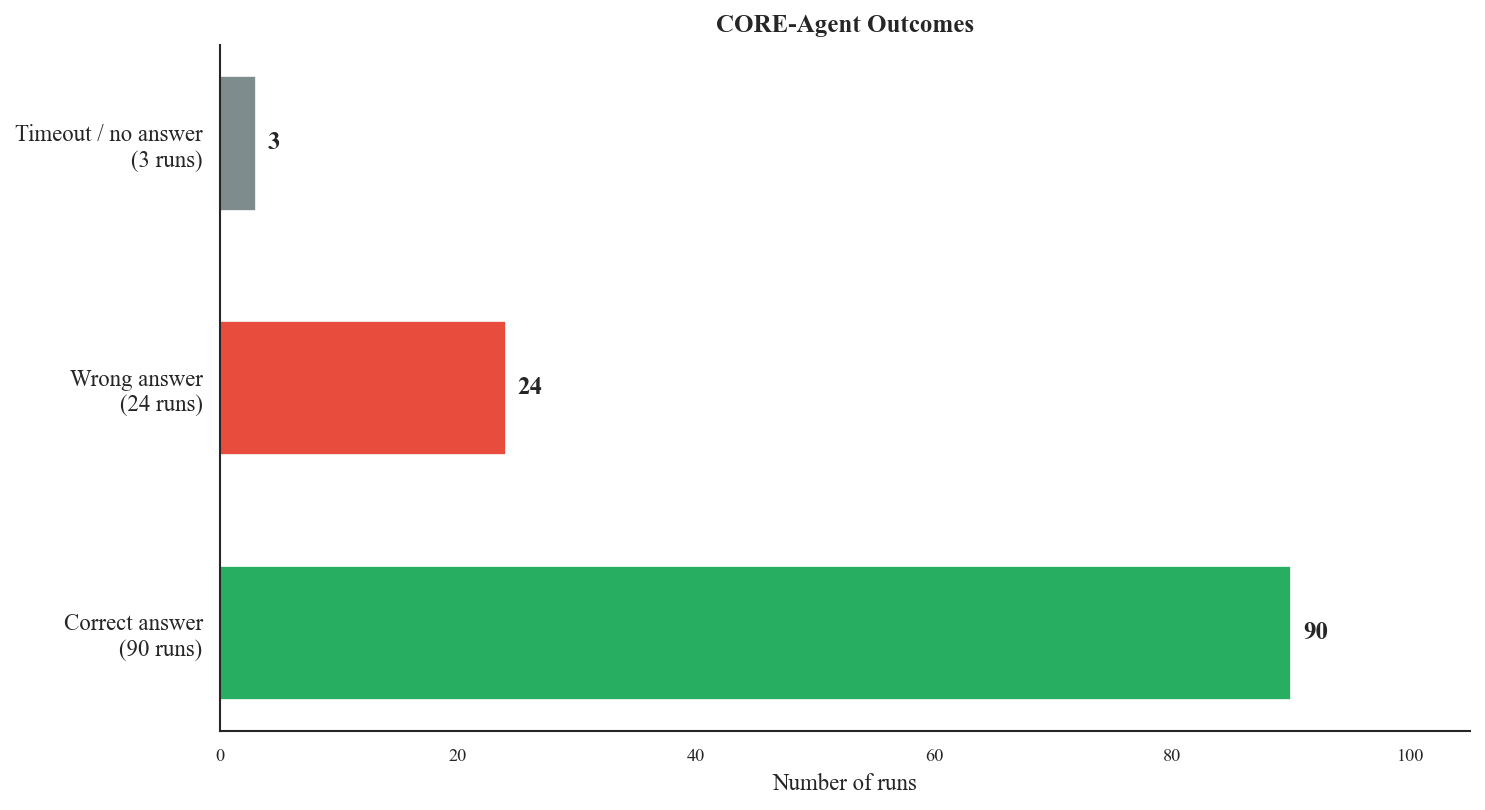

In [ ]:
core_runs = []
for item in data:
    meta = item["agent_run_metadata"]
    if "Core Agent" not in meta["scaffold"]:
        continue
    acc = meta["scores"].get("accuracy", 0)
    fa = str(meta.get("final_answer", ""))

    if acc == 1.0:
        outcome = "pass"
    elif "timed out" in fa:
        outcome = "timeout"
    elif "not produced" in fa:
        outcome = "no_answer"
    else:
        outcome = "wrong_answer"

    used_web_tool = False
    used_vision_tool = False
    for m in item["messages"]:
        tc = m.get("tool_calls") or []
        for call in tc:
            if isinstance(call, dict):
                func = call.get("function", {})
                name = func.get("name", "") if isinstance(func, dict) else ""
                if "visit_webpage" in name or "web_search" in name:
                    used_web_tool = True
                if "vision" in name.lower():
                    used_vision_tool = True

    core_runs.append({
        "accuracy": acc,
        "outcome": outcome,
        "used_web": used_web_tool,
        "used_vision": used_vision_tool,
    })

core_df = pd.DataFrame(core_runs)

fig, ax = plt.subplots(figsize=(10, 5.5))

categories = [
    f"Correct answer\n({len(core_df[core_df['outcome'] == 'pass'])} runs)",
    f"Wrong answer\n({len(core_df[core_df['outcome'] == 'wrong_answer'])} runs)",
    f"Timeout / no answer\n({len(core_df[core_df['outcome'].isin(['timeout', 'no_answer'])])} runs)",
]
values = [
    len(core_df[core_df["outcome"] == "pass"]),
    len(core_df[core_df["outcome"] == "wrong_answer"]),
    len(core_df[core_df["outcome"].isin(["timeout", "no_answer"])]),
]
colors_bar = ["#27ae60", "#e74c3c", "#7f8c8d"]

bars = ax.barh(range(len(categories)), values, color=colors_bar, edgecolor="white", height=0.55)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=12, fontweight="bold")

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=11)
ax.set_xlabel("Number of runs", fontsize=11)
ax.set_title("CORE-Agent Outcomes", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max(values) + 15)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_core_agent_cascade.png")
fig.savefig(FIG_DIR / "behavioral_core_agent_cascade.pdf")
plt.show()

## Capsule Difficulty Spectrum

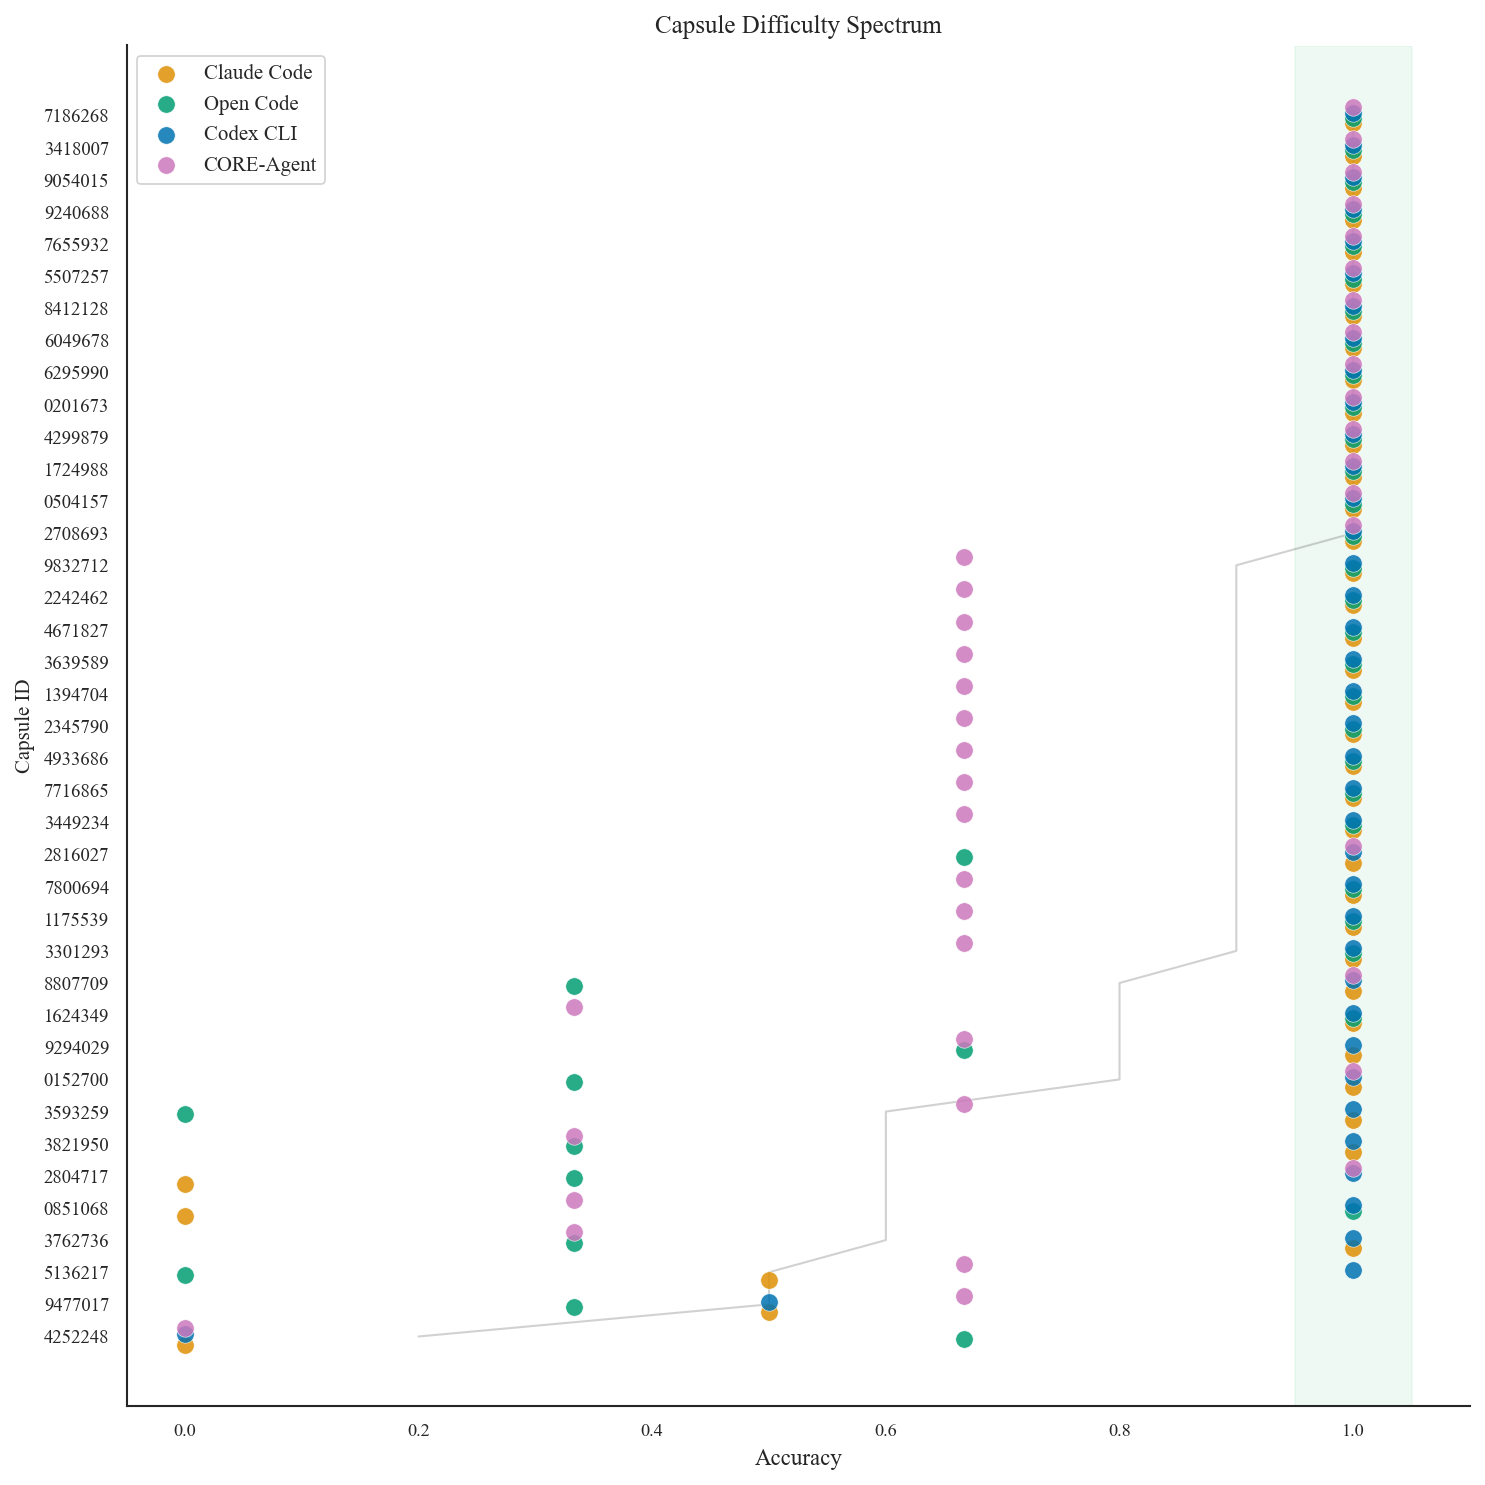

In [ ]:
capsule_stats = []
for capsule in df["capsule_id"].unique():
    cap_df = df[df["capsule_id"] == capsule]
    overall_acc = cap_df["accuracy"].mean()

    family_accs = {}
    for fam in ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]:
        fam_runs = cap_df[cap_df["family"] == fam]
        family_accs[fam] = fam_runs["accuracy"].mean() if len(fam_runs) > 0 else np.nan

    capsule_stats.append({
        "capsule_id": capsule,
        "overall_acc": overall_acc,
        **family_accs,
    })

stats_df = pd.DataFrame(capsule_stats).sort_values("overall_acc")

fig, ax = plt.subplots(figsize=(10, 10))

y_pos = np.arange(len(stats_df))
capsule_labels = [c.replace("capsule-", "") for c in stats_df["capsule_id"]]

offsets = {"Claude Code": -0.25, "Open Code": -0.08, "Codex CLI": 0.08, "CORE-Agent": 0.25}
for fam, offset in offsets.items():
    vals = stats_df[fam].values
    mask = ~np.isnan(vals)
    ax.scatter(vals[mask], y_pos[mask] + offset, c=PALETTE[fam],
               s=70, marker="o", alpha=0.85, label=fam, zorder=3,
               edgecolors="white", linewidths=0.3)

ax.plot(stats_df["overall_acc"].values, y_pos, "k-", alpha=0.2, linewidth=1, zorder=1)
ax.axvspan(0.95, 1.05, alpha=0.07, color="#27ae60", zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(capsule_labels, fontsize=9)
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_ylabel("Capsule ID")
ax.set_title("Capsule Difficulty Spectrum", fontsize=12)
ax.legend(loc="upper left", framealpha=0.9, fontsize=10)
ax.set_xlim(-0.05, 1.1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_difficulty_spectrum.png")
fig.savefig(FIG_DIR / "behavioral_difficulty_spectrum.pdf")
plt.show()

## Scaffold Dominance Matrix

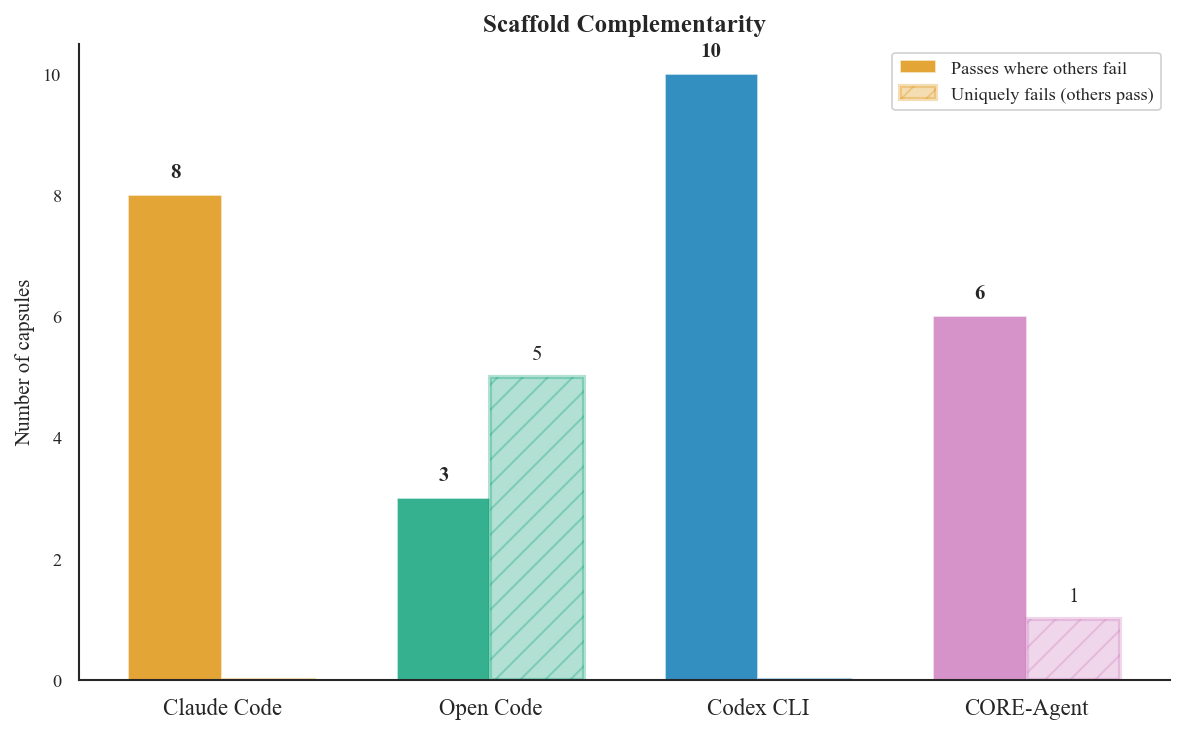

In [ ]:
families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]

saves = defaultdict(lambda: Counter())

for capsule in df["capsule_id"].unique():
    cap_df = df[df["capsule_id"] == capsule]
    family_pass = {}
    for fam in families:
        fam_runs = cap_df[cap_df["family"] == fam]
        family_pass[fam] = fam_runs["accuracy"].mean() if len(fam_runs) > 0 else np.nan

    for fam in families:
        if pd.isna(family_pass[fam]) or family_pass[fam] < 0.5:
            continue
        others_fail = any(
            not pd.isna(family_pass[other]) and family_pass[other] < 0.5
            for other in families if other != fam
        )
        if others_fail:
            saves[fam]["saves"] += 1

    for fam in families:
        if pd.isna(family_pass[fam]) or family_pass[fam] >= 0.5:
            continue
        others_pass = all(
            pd.isna(family_pass[other]) or family_pass[other] >= 0.5
            for other in families if other != fam
        )
        if others_pass:
            saves[fam]["unique_weakness"] += 1

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(families))
width = 0.35

saves_vals = [saves[fam]["saves"] for fam in families]
weak_vals = [saves[fam]["unique_weakness"] for fam in families]

bars1 = ax.bar(x - width/2, saves_vals, width, label="Passes where others fail",
               color=[PALETTE[f] for f in families], alpha=0.8, edgecolor="white")
bars2 = ax.bar(x + width/2, weak_vals, width, label="Uniquely fails (others pass)",
               color=[PALETTE[f] for f in families], alpha=0.3, edgecolor=[PALETTE[f] for f in families],
               linewidth=2, hatch="//")

for bar, val in zip(bars1, saves_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha="center", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, weak_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=11)
ax.set_ylabel("Number of capsules")
ax.set_title("Scaffold Complementarity", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_scaffold_saves.png")
fig.savefig(FIG_DIR / "behavioral_scaffold_saves.pdf")
plt.show()

## Failure Recovery Timeline (Claude Code spiral example)

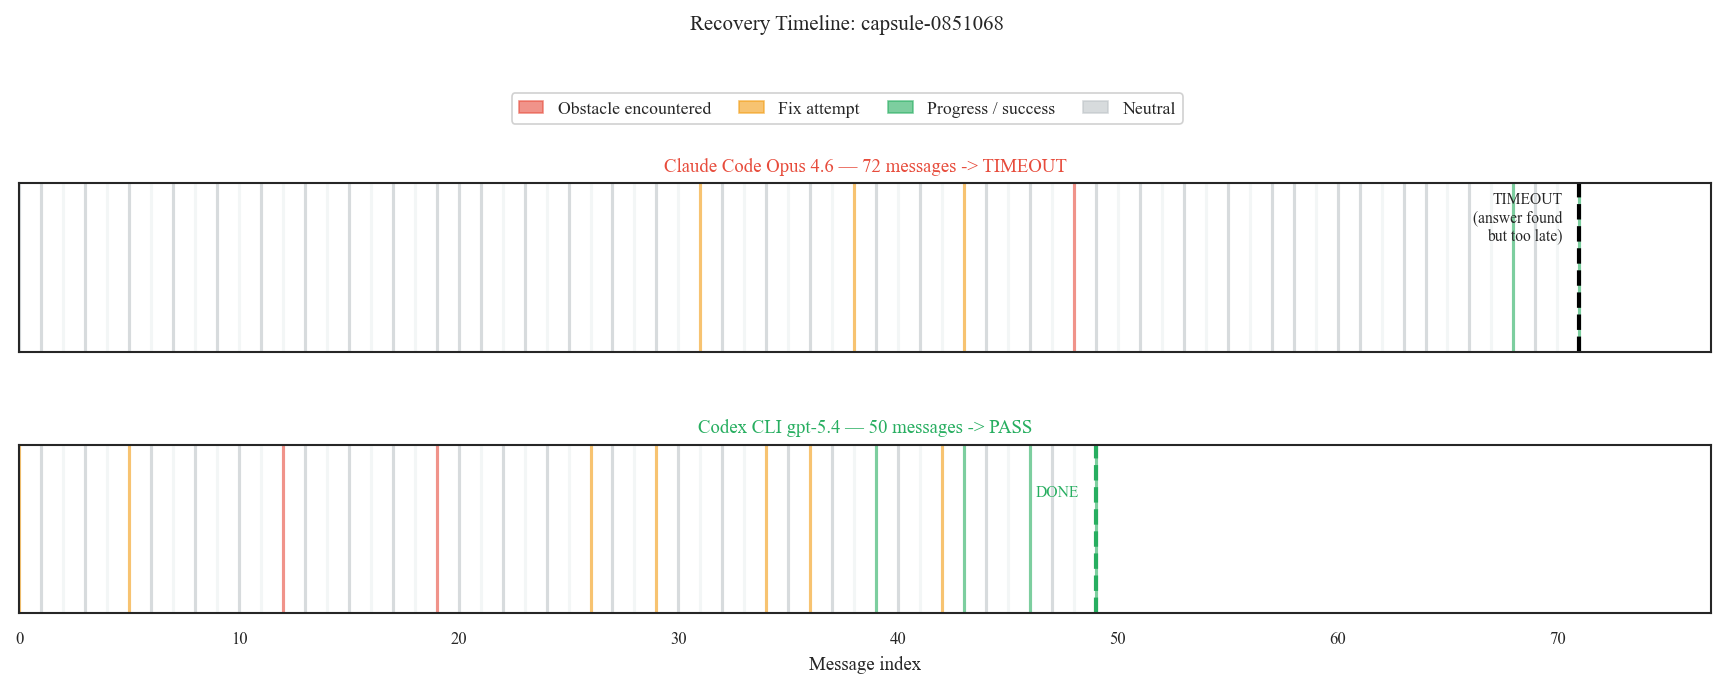

In [ ]:
target_capsule = "capsule-0851068"

cc_run = None
codex_run = None
for item in data:
    meta = item["agent_run_metadata"]
    if meta["capsule_id"] != target_capsule:
        continue
    if "Claude Code (anthropic/claude-opus-4-6)" == meta["scaffold"]:
        cc_run = item
    elif "Codex Agent (gpt-5.4, re=medium)" == meta["scaffold"]:
        codex_run = item

if not cc_run or not codex_run:
    print("SKIPPED - runs not found for capsule-0851068")
else:
    def classify_msgs(item):
        timeline = []
        for i, m in enumerate(item["messages"]):
            role = m.get("role", "")
            content = str(m.get("content", "")).lower()
            if role == "assistant":
                if any(kw in content for kw in ["error", "failed", "issue", "problem", "cannot", "missing"]):
                    timeline.append(("obstacle", i))
                elif any(kw in content for kw in ["fix", "install", "workaround", "modify", "patch"]):
                    timeline.append(("fix_attempt", i))
                elif any(kw in content for kw in ["success", "complete", "answer", "auc", "result"]):
                    timeline.append(("progress", i))
                else:
                    timeline.append(("neutral", i))
            elif role == "user":
                timeline.append(("tool_result", i))
        return timeline

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4.7), sharex=True)

    cc_colors = {"obstacle": "#e74c3c", "fix_attempt": "#f39c12", "progress": "#27ae60",
                 "neutral": "#bdc3c7", "tool_result": "#ecf0f1"}

    cc_timeline = classify_msgs(cc_run)
    for event_type, idx in cc_timeline:
        ax1.axvline(idx, color=cc_colors[event_type], alpha=0.6, linewidth=1.5)

    ax1.axvline(len(cc_run["messages"])-1, color="black", linewidth=2, linestyle="--")
    ax1.annotate(
        "TIMEOUT\n(answer found\nbut too late)",
        xy=(len(cc_run["messages"])-1, 0.8),
        xycoords=ax1.get_xaxis_transform(),
        xytext=(-8, 0), textcoords="offset points",
        ha="right", va="center", fontsize=7.5,
    )
    ax1.set_title(f"Claude Code Opus 4.6 — {len(cc_run['messages'])} messages -> TIMEOUT",
                  fontsize=9, color="#e74c3c", pad=6)
    ax1.set_xlim(0, max(len(cc_run["messages"]), len(codex_run["messages"])) + 5)
    ax1.set_yticks([])

    codex_timeline = classify_msgs(codex_run)
    for event_type, idx in codex_timeline:
        ax2.axvline(idx, color=cc_colors[event_type], alpha=0.6, linewidth=1.5)

    ax2.axvline(len(codex_run["messages"])-1, color="#27ae60", linewidth=2, linestyle="--")
    ax2.annotate(
        "DONE",
        xy=(len(codex_run["messages"])-1, 0.72),
        xycoords=ax2.get_xaxis_transform(),
        xytext=(-8, 0), textcoords="offset points",
        ha="right", va="center", fontsize=7.5, color="#27ae60",
    )
    ax2.set_title(f"Codex CLI gpt-5.4 — {len(codex_run['messages'])} messages -> PASS",
                  fontsize=9, color="#27ae60", pad=6)
    ax2.set_xlim(0, max(len(cc_run["messages"]), len(codex_run["messages"])) + 5)
    ax2.set_yticks([])
    ax2.set_xlabel("Message index", fontsize=9)
    ax2.tick_params(axis="x", labelsize=8)

    legend_elements = [
        mpatches.Patch(color="#e74c3c", alpha=0.6, label="Obstacle encountered"),
        mpatches.Patch(color="#f39c12", alpha=0.6, label="Fix attempt"),
        mpatches.Patch(color="#27ae60", alpha=0.6, label="Progress / success"),
        mpatches.Patch(color="#bdc3c7", alpha=0.6, label="Neutral"),
    ]
    fig.legend(handles=legend_elements, loc="upper center", ncol=4, framealpha=0.9,
               bbox_to_anchor=(0.5, 0.88), fontsize=8.5, handlelength=1.4, columnspacing=1.6)

    fig.suptitle("Recovery Timeline: capsule-0851068", fontsize=10, y=0.98)
    fig.subplots_adjust(left=0.04, right=0.98, bottom=0.13, top=0.74, hspace=0.55)
    fig.savefig(FIG_DIR / "behavioral_spiral_timeline.png")
    plt.show()

##  Wrong-Value Taxonomy

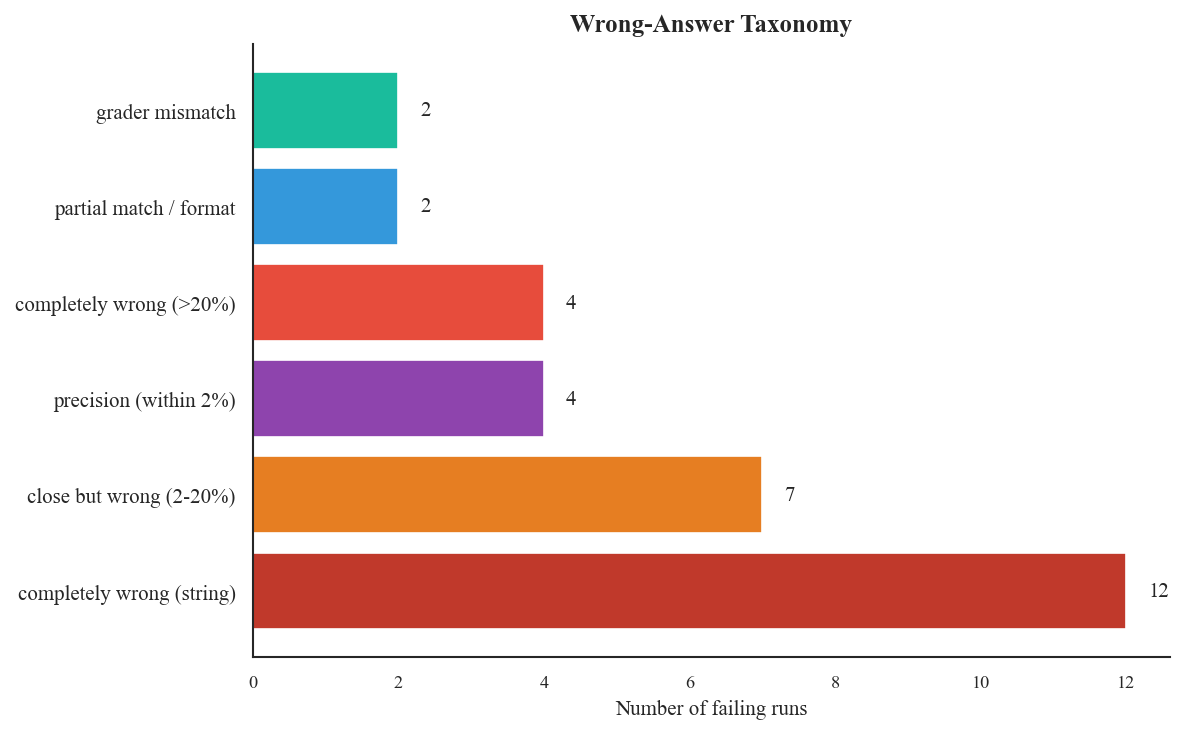

In [ ]:
taxonomy = Counter()
for item in data:
    meta = item["agent_run_metadata"]
    if meta["scores"].get("accuracy", 0) != 0.0:
        continue
    fa = meta.get("final_answer")
    if not fa or str(fa).startswith("ERROR"):
        continue

    capsule = meta["capsule_id"]
    gt = gt_by_capsule.get(capsule, [])
    if not gt:
        taxonomy["no_gt"] += 1
        continue

    if isinstance(fa, dict) and gt:
        gt_dict = gt[0] if isinstance(gt[0], dict) else {}
        for q_key in fa:
            reported = fa[q_key]
            expected = gt_dict.get(q_key)
            if expected is None:
                continue

            try:
                r_val = float(str(reported).replace("%", ""))
                e_val = float(str(expected))
                rel_error = abs(r_val - e_val) / abs(e_val) if e_val != 0 else abs(r_val)
                if rel_error < 0.02:
                    taxonomy["precision (within 2%)"] += 1
                elif rel_error < 0.2:
                    taxonomy["close but wrong (2-20%)"] += 1
                else:
                    taxonomy["completely wrong (>20%)"] += 1
            except (ValueError, TypeError):
                r_str = str(reported).strip().lower()
                e_str = str(expected).strip().lower() if not isinstance(expected, list) else str(expected)
                if r_str == e_str:
                    taxonomy["grader mismatch"] += 1
                elif any(part in r_str for part in e_str.split()):
                    taxonomy["partial match / format"] += 1
                else:
                    taxonomy["completely wrong (string)"] += 1
            break

fig, ax = plt.subplots(figsize=(8, 5))

labels = list(taxonomy.keys())
values = list(taxonomy.values())

sorted_pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_pairs)

color_map = {
    "precision (within 2%)": "#8e44ad",
    "close but wrong (2-20%)": "#e67e22",
    "completely wrong (>20%)": "#e74c3c",
    "completely wrong (string)": "#c0392b",
    "partial match / format": "#3498db",
    "grader mismatch": "#1abc9c",
    "no_gt": "#7f8c8d",
}
colors = [color_map.get(l, "#95a5a6") for l in labels]

bars = ax.barh(range(len(labels)), values, color=colors, edgecolor="white")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Number of failing runs")
ax.set_title("Wrong-Answer Taxonomy", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_wrong_value_taxonomy.png")
plt.show()

## Wrong-Answer Taxonomy by Scaffold Family

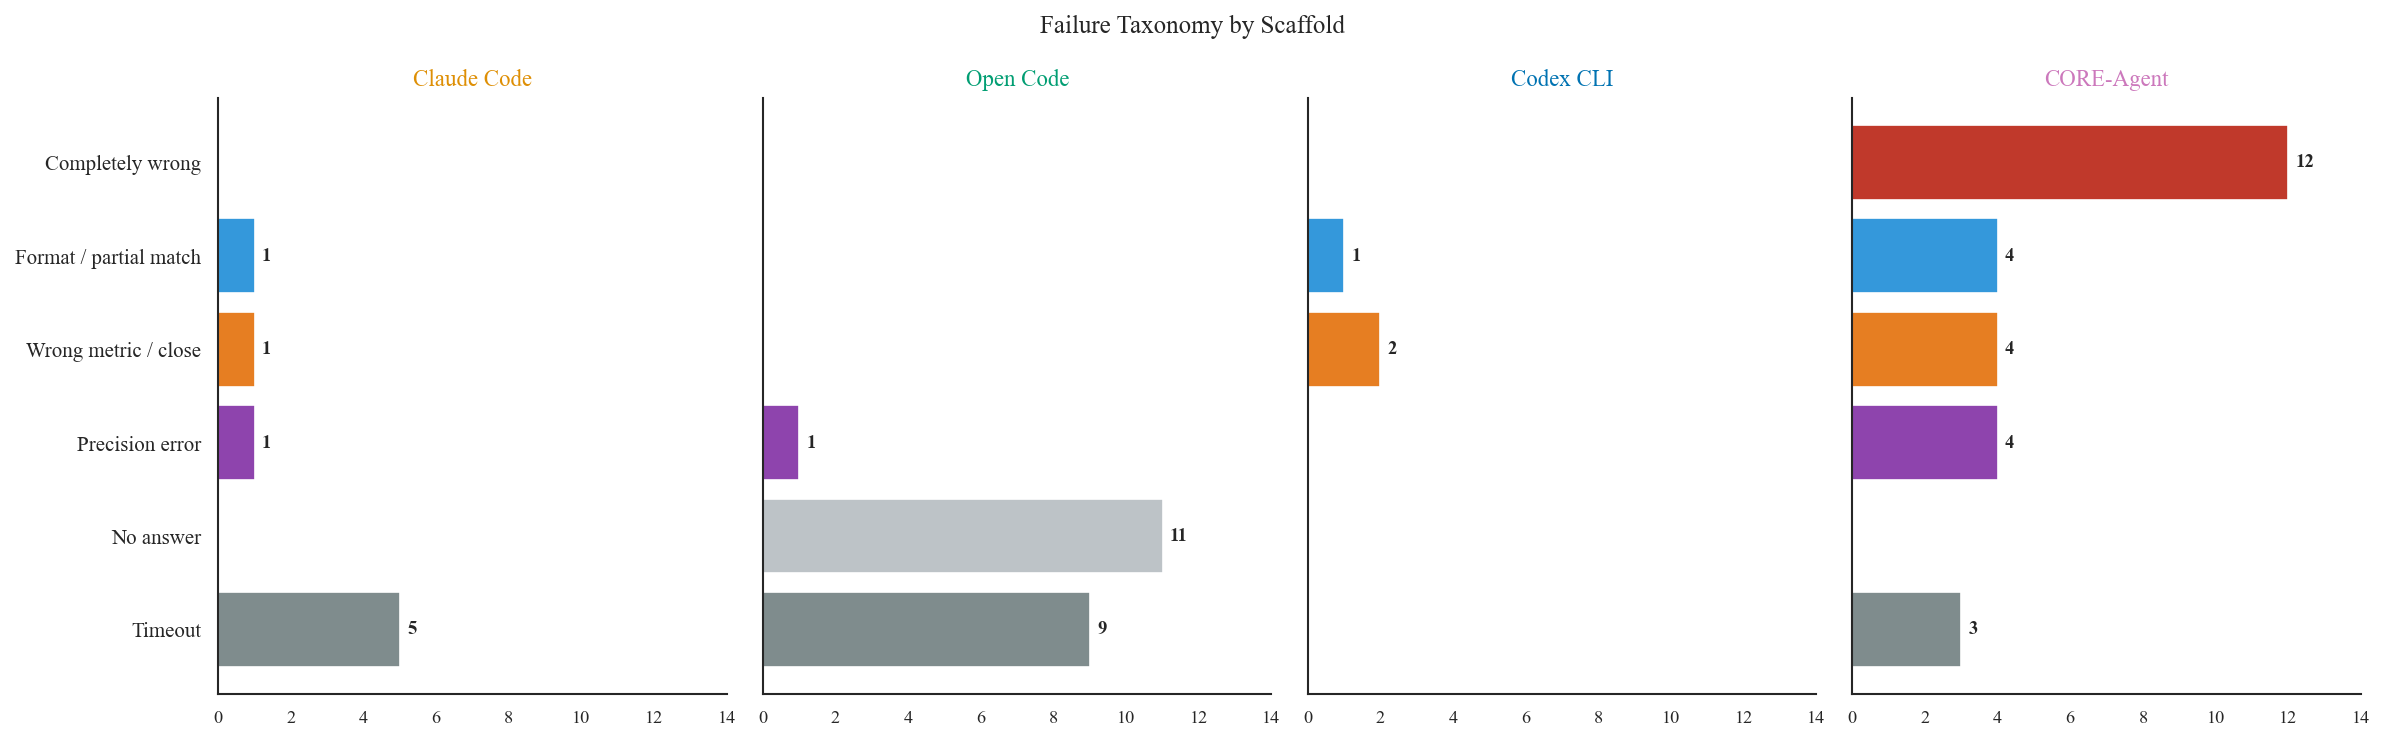

In [ ]:
families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]

family_taxonomy = {fam: Counter() for fam in families}
for item in data:
    meta = item["agent_run_metadata"]
    if meta["scores"].get("accuracy", 0) != 0.0:
        continue
    fa = meta.get("final_answer")
    fa_str = str(fa) if fa else ""
    family = get_family(meta["scaffold"])

    if "timed out" in fa_str:
        family_taxonomy[family]["Timeout"] += 1
    elif "not produced" in fa_str:
        family_taxonomy[family]["No answer"] += 1
    elif fa and not fa_str.startswith("ERROR"):
        capsule = meta["capsule_id"]
        gt = gt_by_capsule.get(capsule, [])
        if not gt:
            family_taxonomy[family]["Wrong (no GT)"] += 1
            continue
        if isinstance(fa, dict) and gt:
            gt_dict = gt[0] if isinstance(gt[0], dict) else {}
            classified = False
            for q_key in fa:
                expected = gt_dict.get(q_key)
                reported = fa[q_key]
                if expected is None:
                    continue
                try:
                    r_val = float(str(reported).replace("%", ""))
                    e_val = float(str(expected))
                    rel_error = abs(r_val - e_val) / abs(e_val) if e_val != 0 else abs(r_val)
                    if rel_error < 0.02:
                        family_taxonomy[family]["Precision error"] += 1
                    elif rel_error < 0.2:
                        family_taxonomy[family]["Wrong metric / close"] += 1
                    else:
                        family_taxonomy[family]["Completely wrong"] += 1
                    classified = True
                except (ValueError, TypeError):
                    r_str = str(reported).strip().lower()
                    e_str = str(expected).strip().lower() if not isinstance(expected, list) else str(expected).lower()
                    if r_str == e_str:
                        family_taxonomy[family]["Precision error"] += 1
                    elif any(part in r_str for part in e_str.split()) or any(part in e_str for part in r_str.split()):
                        family_taxonomy[family]["Format / partial match"] += 1
                    else:
                        family_taxonomy[family]["Completely wrong"] += 1
                    classified = True
                break
            if not classified:
                family_taxonomy[family]["Unclassified"] += 1

categories = ["Timeout", "No answer", "Precision error", "Wrong metric / close",
              "Format / partial match", "Completely wrong"]
cat_colors = {
    "Timeout": "#7f8c8d", "No answer": "#bdc3c7", "Precision error": "#8e44ad",
    "Wrong metric / close": "#e67e22", "Format / partial match": "#3498db",
    "Completely wrong": "#c0392b",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, fam in zip(axes, families):
    vals = [family_taxonomy[fam].get(cat, 0) for cat in categories]
    colors = [cat_colors[cat] for cat in categories]
    bars = ax.barh(range(len(categories)), vals, color=colors, edgecolor="white")
    ax.set_title(fam, fontsize=11, color=PALETTE[fam])
    ax.set_xlim(0, max(max(v for v in family_taxonomy[f].values()) for f in families if family_taxonomy[f]) + 2)

    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                    str(val), va="center", fontsize=9, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_yticks(range(len(categories)))
axes[0].set_yticklabels(categories, fontsize=10)
fig.suptitle("Failure Taxonomy by Scaffold", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_taxonomy_by_scaffold.png")
plt.show()

## Efficiency vs Accuracy with Failure Mode Markers

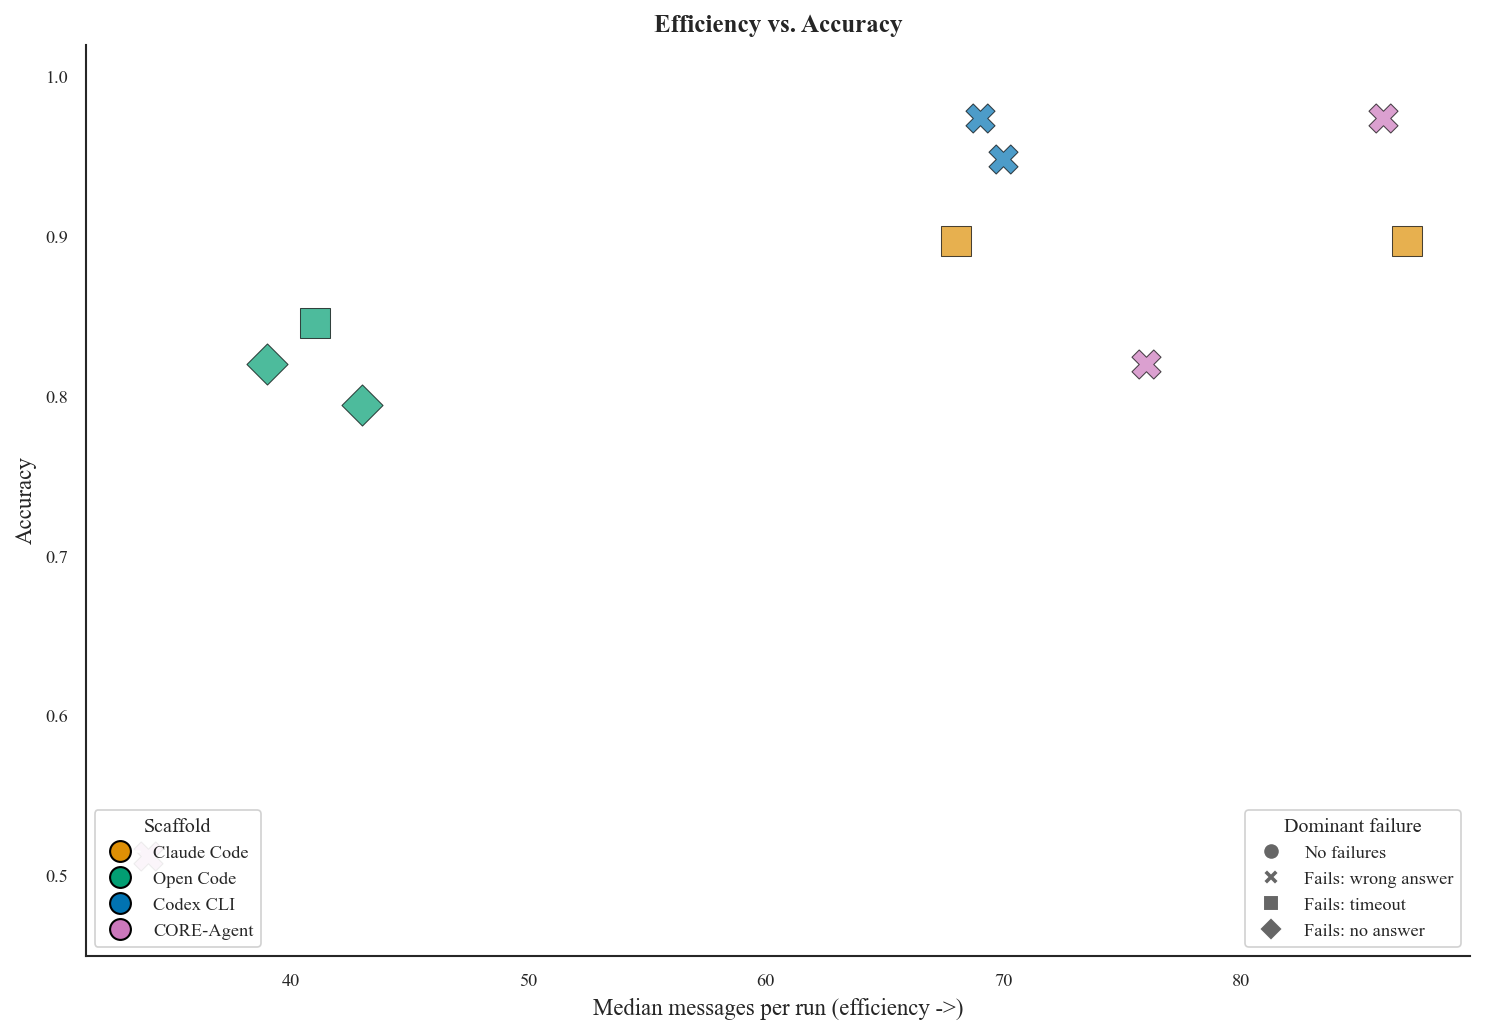

In [ ]:
config_stats = []
for config, grp in df.groupby("scaffold"):
    family = get_family(config)
    acc = grp["accuracy"].mean()
    med_msgs = grp["msg_count"].median()
    n_runs = len(grp)
    n_fail = len(grp[grp["accuracy"] == 0])
    fail_types = grp[grp["accuracy"] == 0]["failure_type"].value_counts().to_dict()
    dominant_fail = max(fail_types, key=fail_types.get) if fail_types else "none"
    config_stats.append({
        "config": config, "family": family, "accuracy": acc,
        "median_msgs": med_msgs, "n_runs": n_runs,
        "dominant_fail": dominant_fail,
    })

cdf = pd.DataFrame(config_stats)

fail_markers = {"none": "o", "wrong_answer": "X", "timeout": "s",
                "no_answer": "D", "other_error": "P"}

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in cdf.iterrows():
    marker = fail_markers.get(row["dominant_fail"], "o")
    ax.scatter(row["median_msgs"], row["accuracy"],
               c=PALETTE.get(row["family"], "#999"),
               s=row["n_runs"] * 5, marker=marker, alpha=0.7,
               edgecolors="black", linewidths=0.5, zorder=3)

family_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[f],
           markersize=10, markeredgecolor="black", label=f)
    for f in ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]
]
fail_handles = [
    Line2D([0], [0], marker=fail_markers[m], color="w", markerfacecolor="#666",
           markersize=8, label=l, linestyle="None")
    for m, l in [("none", "No failures"), ("wrong_answer", "Fails: wrong answer"),
                 ("timeout", "Fails: timeout"), ("no_answer", "Fails: no answer")]
]

leg1 = ax.legend(handles=family_handles, loc="lower left", title="Scaffold", framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=fail_handles, loc="lower right", title="Dominant failure", framealpha=0.9)

ax.set_xlabel("Median messages per run (efficiency ->)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Efficiency vs. Accuracy", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0.45, 1.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_efficiency_accuracy.png")
plt.show()

## Figure 14: GPT-5.4 CORE-Agent Failure Pattern

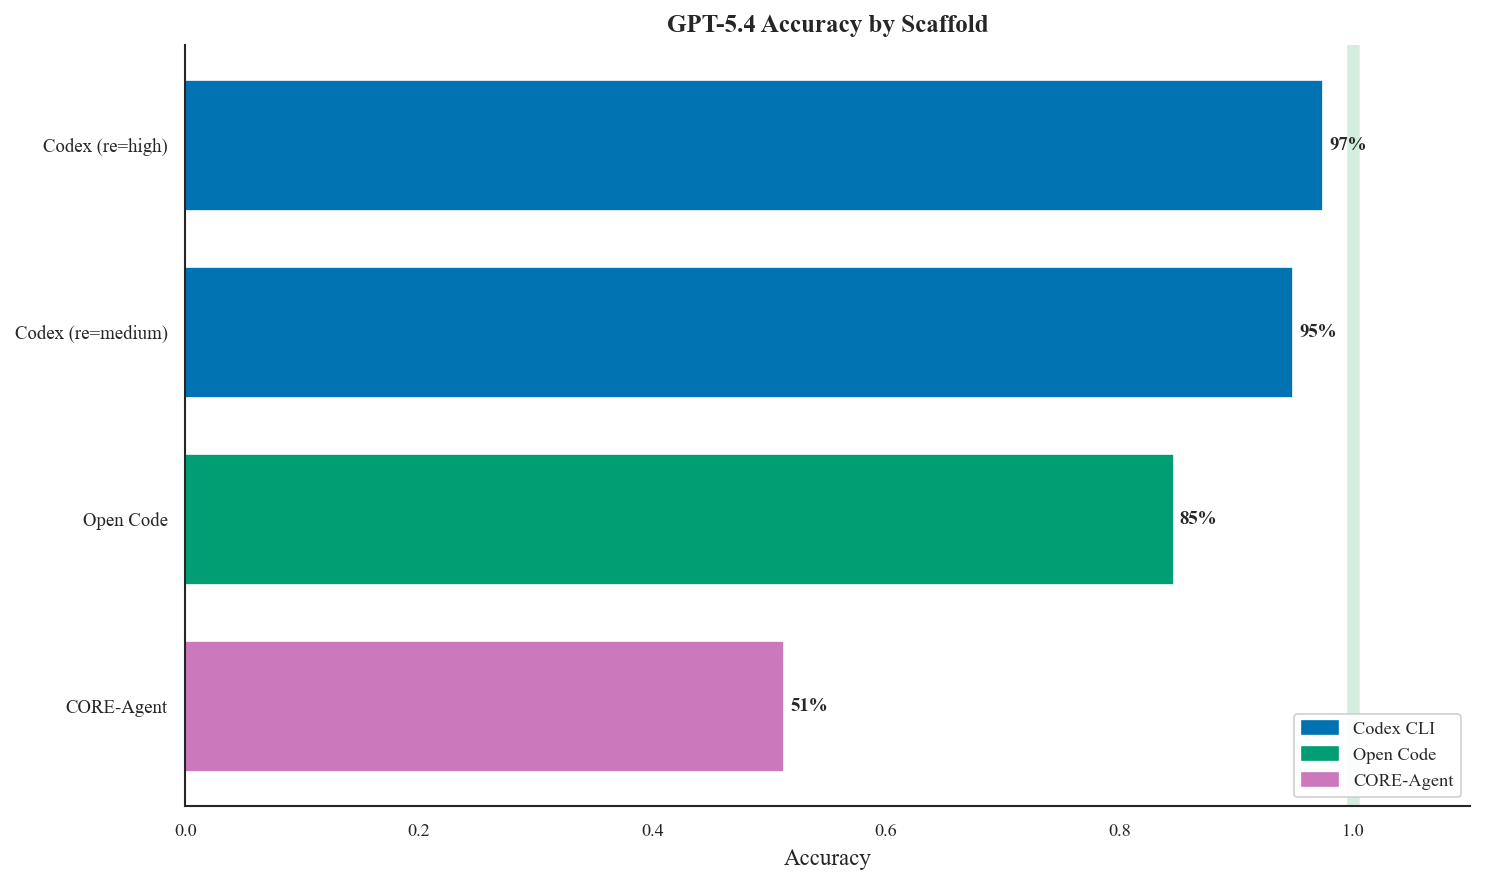

In [ ]:
gpt54 = df[df["model"].str.contains("5.4", na=False)].copy()

def short_name(s):
    if "Core Agent" in s:
        return "CORE-Agent"
    elif "Open Code" in s:
        return "Open Code"
    elif "Codex" in s:
        parts = s.split("(")[1].rstrip(")") if "(" in s else s
        return f"Codex ({parts.split(',',1)[-1].strip()})" if "," in parts else "Codex"
    return s[:25]

scaffold_acc = (
    gpt54.groupby("scaffold")["accuracy"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy", "count": "n_runs"})
    .sort_values("accuracy")
)
scaffold_acc["family"] = [get_family(s) for s in scaffold_acc.index]
scaffold_acc["short"] = [short_name(s) for s in scaffold_acc.index]

fig, ax = plt.subplots(figsize=(10, 6))

colors = [PALETTE.get(fam, "#999") for fam in scaffold_acc["family"]]
bars = ax.barh(range(len(scaffold_acc)), scaffold_acc["accuracy"].values,
               color=colors, edgecolor="white", height=0.7)

ax.set_yticks(range(len(scaffold_acc)))
ax.set_yticklabels(scaffold_acc["short"].values, fontsize=9)
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_title("GPT-5.4 Accuracy by Scaffold", fontsize=12, fontweight="bold")
ax.axvline(1.0, color="#27ae60", alpha=0.2, linewidth=6, zorder=0)

for bar, acc in zip(bars, scaffold_acc["accuracy"].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{acc:.0%}", va="center", fontsize=9, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 1.1)

family_handles = [
    mpatches.Patch(color=PALETTE[f], label=f)
    for f in ["Codex CLI", "Open Code", "CORE-Agent"]
]
ax.legend(handles=family_handles, loc="lower right", framealpha=0.9)

fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_core_agent_outlier.png")
plt.show()

## Root-Cause Taxonomy by Scaffold

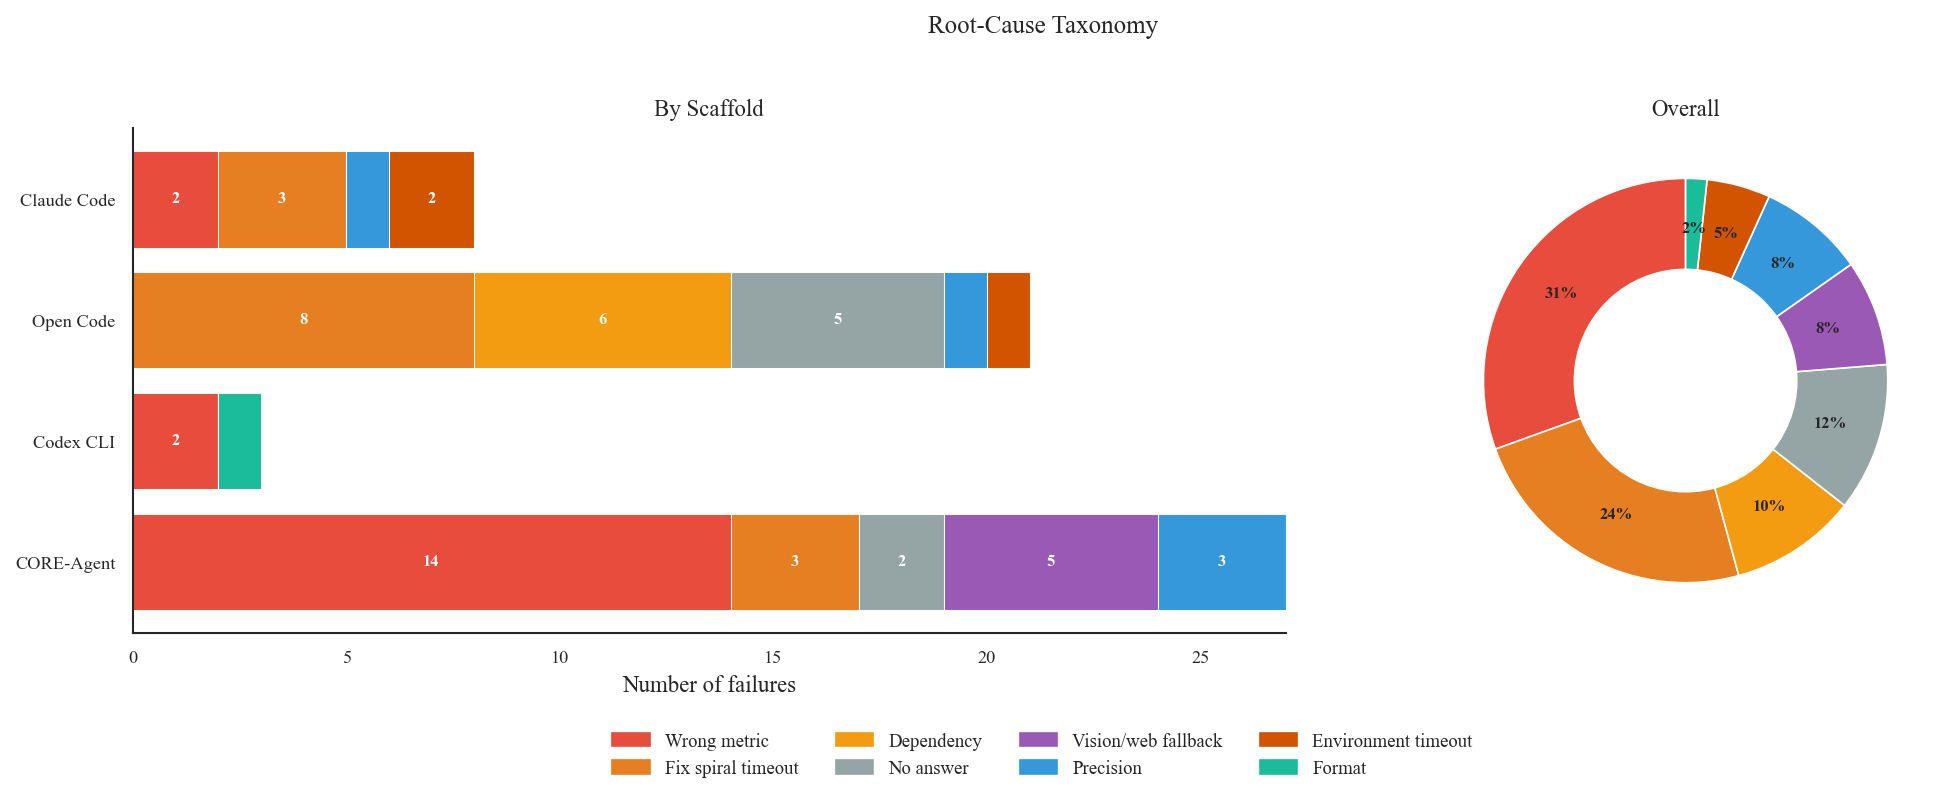

In [ ]:
ROOT_CAUSE_CLASSIFICATIONS = [
    ("capsule-0152700", "Open Code", "claude-opus-4-6", "gave_up"),
    ("capsule-0152700", "Open Code", "gpt-5.4", "timeout_spiral"),
    ("capsule-0851068", "Claude Code", "claude-opus-4-5", "timeout_env"),
    ("capsule-0851068", "Claude Code", "claude-opus-4-6", "timeout_env"),
    ("capsule-0851068", "CORE-Agent", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-0851068", "CORE-Agent", "gpt-5.4", "vision_fallback"),
    ("capsule-1175539", "CORE-Agent", "gpt-5.4", "gave_up"),
    ("capsule-1394704", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-1624349", "CORE-Agent", "claude-opus-4-5", "precision"),
    ("capsule-1624349", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-2242462", "CORE-Agent", "gpt-5.4", "gave_up"),
    ("capsule-2345790", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-2804717", "Claude Code", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-2804717", "Claude Code", "claude-opus-4-6", "timeout_spiral"),
    ("capsule-2804717", "Open Code", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-2804717", "Open Code", "claude-opus-4-6", "timeout_spiral"),
    ("capsule-2816027", "Open Code", "gpt-5.4", "timeout_spiral"),
    ("capsule-3301293", "CORE-Agent", "claude-opus-4-5", "wrong_metric"),
    ("capsule-3449234", "CORE-Agent", "gpt-5.4", "vision_fallback"),
    ("capsule-3593259", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-3593259", "Open Code", "claude-opus-4-5", "gave_up"),
    ("capsule-3593259", "Open Code", "claude-opus-4-6", "dependency"),
    ("capsule-3593259", "Open Code", "gpt-5.4", "dependency"),
    ("capsule-3639589", "CORE-Agent", "claude-opus-4-5", "vision_fallback"),
    ("capsule-3762736", "CORE-Agent", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-3762736", "CORE-Agent", "gpt-5.4", "timeout_spiral"),
    ("capsule-3762736", "Open Code", "claude-opus-4-5", "gave_up"),
    ("capsule-3762736", "Open Code", "gpt-5.4", "timeout_env"),
    ("capsule-3821950", "CORE-Agent", "claude-opus-4-5", "vision_fallback"),
    ("capsule-3821950", "CORE-Agent", "gpt-5.4", "vision_fallback"),
    ("capsule-3821950", "Open Code", "claude-opus-4-5", "dependency"),
    ("capsule-3821950", "Open Code", "claude-opus-4-6", "dependency"),
    ("capsule-4252248", "Claude Code", "claude-opus-4-5", "wrong_metric"),
    ("capsule-4252248", "Claude Code", "claude-opus-4-6", "precision"),
    ("capsule-4252248", "Codex CLI", "gpt-5.4", "wrong_metric"),
    ("capsule-4252248", "Codex CLI", "gpt-5.4", "wrong_metric"),
    ("capsule-4252248", "CORE-Agent", "claude-opus-4-5", "wrong_metric"),
    ("capsule-4252248", "CORE-Agent", "claude-opus-4-6", "precision"),
    ("capsule-4252248", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-4252248", "Open Code", "claude-opus-4-6", "precision"),
    ("capsule-4671827", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-4933686", "CORE-Agent", "gpt-5.4", "precision"),
    ("capsule-5136217", "Claude Code", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-5136217", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-5136217", "Open Code", "claude-opus-4-5", "timeout_spiral"),
    ("capsule-5136217", "Open Code", "claude-opus-4-6", "timeout_spiral"),
    ("capsule-5136217", "Open Code", "gpt-5.4", "timeout_spiral"),
    ("capsule-7716865", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-7800694", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-8807709", "Open Code", "claude-opus-4-5", "dependency"),
    ("capsule-8807709", "Open Code", "claude-opus-4-6", "dependency"),
    ("capsule-9294029", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-9294029", "Open Code", "gpt-5.4", "timeout_spiral"),
    ("capsule-9477017", "Claude Code", "claude-opus-4-6", "wrong_metric"),
    ("capsule-9477017", "Codex CLI", "gpt-5.4", "format"),
    ("capsule-9477017", "CORE-Agent", "gpt-5.4", "wrong_metric"),
    ("capsule-9477017", "Open Code", "claude-opus-4-5", "gave_up"),
    ("capsule-9477017", "Open Code", "claude-opus-4-6", "gave_up"),
    ("capsule-9832712", "CORE-Agent", "gpt-5.4", "wrong_metric"),
]

rc_df = pd.DataFrame(ROOT_CAUSE_CLASSIFICATIONS,
                     columns=["capsule", "scaffold", "model", "root_cause"])

CAUSE_ORDER = ["wrong_metric", "timeout_spiral", "dependency",
               "gave_up", "vision_fallback", "precision",
               "timeout_env", "format"]
CAUSE_LABELS = {
    "wrong_metric": "Wrong metric",
    "timeout_spiral": "Fix spiral timeout",
    "dependency": "Dependency",
    "gave_up": "No answer",
    "vision_fallback": "Vision/web fallback",
    "precision": "Precision",
    "timeout_env": "Environment timeout",
    "format": "Format",
}
CAUSE_COLORS = {
    "wrong_metric": "#e74c3c",
    "timeout_spiral": "#e67e22",
    "dependency": "#f39c12",
    "gave_up": "#95a5a6",
    "vision_fallback": "#9b59b6",
    "precision": "#3498db",
    "timeout_env": "#d35400",
    "format": "#1abc9c",
}

families = ["Claude Code", "Open Code", "Codex CLI", "CORE-Agent"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 2]})

# Left: stacked bar by scaffold
ax = axes[0]
ct = pd.crosstab(rc_df["scaffold"], rc_df["root_cause"])
for cause in CAUSE_ORDER:
    if cause not in ct.columns:
        ct[cause] = 0
ct = ct[CAUSE_ORDER]
ct = ct.reindex(families)

bottoms = np.zeros(len(families))
for cause in CAUSE_ORDER:
    vals = ct[cause].values
    if vals.sum() == 0:
        continue
    bars = ax.barh(families, vals, left=bottoms, color=CAUSE_COLORS[cause],
                   label=CAUSE_LABELS[cause], edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v >= 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    str(v), ha="center", va="center", fontsize=8, fontweight="bold", color="white")
    bottoms += vals

ax.set_xlabel("Number of failures", fontsize=11)
ax.set_title("By Scaffold", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

# Right: overall donut
ax2 = axes[1]
totals = rc_df["root_cause"].value_counts()
sizes = [totals.get(c, 0) for c in CAUSE_ORDER]
colors = [CAUSE_COLORS[c] for c in CAUSE_ORDER]
labels = [CAUSE_LABELS[c] for c in CAUSE_ORDER]
nonzero = [(s, c, l) for s, c, l in zip(sizes, colors, labels) if s > 0]
sizes_nz, colors_nz, labels_nz = zip(*nonzero)

wedges, texts, autotexts = ax2.pie(
    sizes_nz, colors=colors_nz, autopct=lambda p: f"{p:.0f}%",
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor="white"))
for t in autotexts:
    t.set_fontsize(8)
    t.set_fontweight("bold")
ax2.set_title("Overall", fontsize=11)

handles = [mpatches.Patch(color=CAUSE_COLORS[c], label=CAUSE_LABELS[c])
           for c in CAUSE_ORDER if totals.get(c, 0) > 0]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Root-Cause Taxonomy", fontsize=12, y=1.02)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIG_DIR / "behavioral_root_cause_taxonomy.png", bbox_inches="tight")
plt.show()

## Rubric v2 Analysis

In [ ]:
rubric_path = Path("data/rubric_v2_results.json")
with open(rubric_path) as f:
    rdata = json.load(f)

### Answer Source by Scaffold

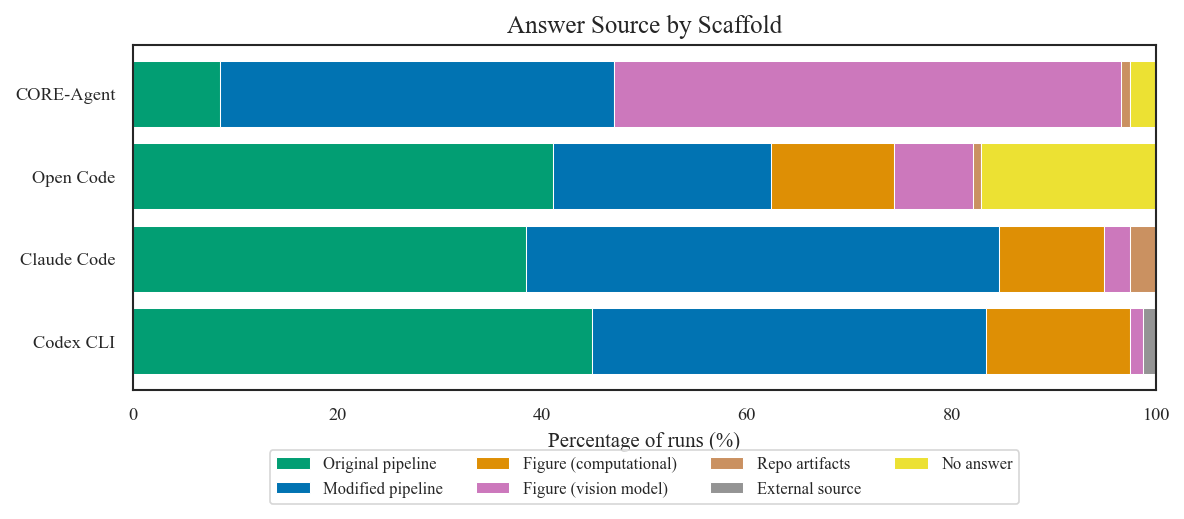

In [ ]:
rows = []
for r in rdata:
    if r.get("result_type") != "DIRECT_RESULT":
        continue
    out = r["output"]
    rows.append({
        "family": get_family(r["scaffold"]),
        "answer_source": out["answer_source"],
    })
rdf = pd.DataFrame(rows)

source_order = [
    "original_pipeline", "modified_pipeline", "figure_computational",
    "figure_visual", "repo_artifacts", "external_source", "no_answer",
]
source_labels = {
    "original_pipeline": "Original pipeline",
    "modified_pipeline": "Modified pipeline",
    "figure_computational": "Figure (computational)",
    "figure_visual": "Figure (vision model)",
    "repo_artifacts": "Repo artifacts",
    "external_source": "External source",
    "no_answer": "No answer",
}
_cb = sns.color_palette("colorblind", 10)
source_colors = {
    "original_pipeline": _cb[2],
    "modified_pipeline": _cb[0],
    "figure_computational": _cb[1],
    "figure_visual": _cb[4],
    "repo_artifacts": _cb[5],
    "external_source": _cb[7],
    "no_answer": _cb[8],
}

family_order = ["Codex CLI", "Claude Code", "Open Code", "CORE-Agent"]
fig, ax = plt.subplots(figsize=(8, 4))

bottoms = {fam: 0 for fam in family_order}
for src in source_order:
    widths = []
    for fam in family_order:
        sub = rdf[rdf["family"] == fam]
        total = len(sub)
        count = len(sub[sub["answer_source"] == src])
        widths.append(count / total * 100 if total > 0 else 0)

    bars = ax.barh(
        family_order, widths, left=[bottoms[f] for f in family_order],
        color=source_colors[src], label=source_labels[src],
        edgecolor="white", linewidth=0.5,
    )
    for i, fam in enumerate(family_order):
        bottoms[fam] += widths[i]

ax.set_xlabel("Percentage of runs (%)")
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)
ax.set_title("Answer Source by Scaffold")
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIG_DIR / "behavioral_answer_source.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "behavioral_answer_source.pdf", bbox_inches="tight")
plt.show()

### Resolution Strategy Success Rate

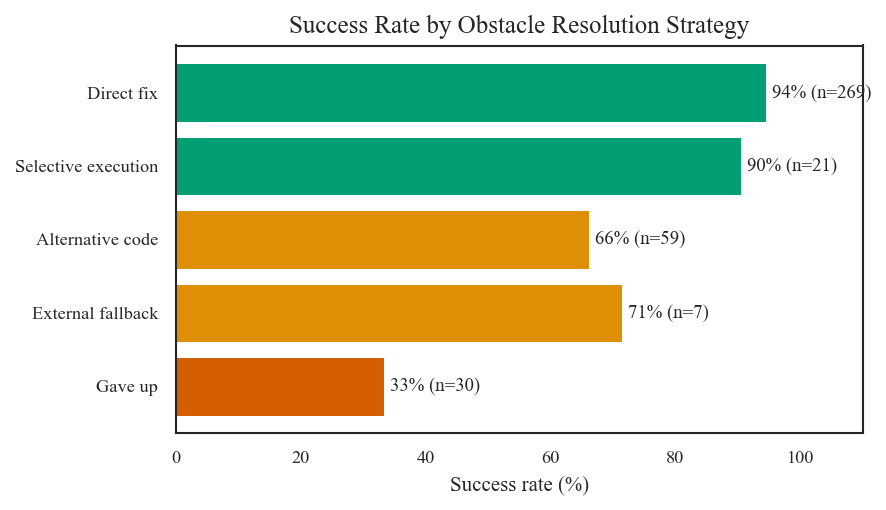

In [ ]:
rows = []
for r in rdata:
    if r.get("result_type") != "DIRECT_RESULT":
        continue
    out = r["output"]
    rows.append({
        "obstacle_resolution": out["obstacle_resolution"],
        "accuracy": r["accuracy"],
    })
rdf = pd.DataFrame(rows)

res_order = [
    "direct_fix", "selective_execution", "alternative_code",
    "external_fallback", "gave_up",
]
res_labels = {
    "direct_fix": "Direct fix",
    "selective_execution": "Selective execution",
    "alternative_code": "Alternative code",
    "external_fallback": "External fallback",
    "gave_up": "Gave up",
}

rdf_filtered = rdf[rdf["obstacle_resolution"].isin(res_order)]
stats = rdf_filtered.groupby("obstacle_resolution").agg(
    success_rate=("accuracy", "mean"),
    n=("accuracy", "count"),
).reindex(res_order)

fig, ax = plt.subplots(figsize=(6, 3.5))
_cb = sns.color_palette("colorblind", 10)
colors = [_cb[2], _cb[2], _cb[1], _cb[1], _cb[3]]
bars = ax.barh(
    [res_labels[r] for r in res_order],
    stats["success_rate"] * 100,
    color=colors, edgecolor="white", linewidth=0.5,
)

for bar, (_, row) in zip(bars, stats.iterrows()):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{row['success_rate']*100:.0f}% (n={int(row['n'])})",
        va="center", fontsize=9,
    )

ax.set_xlabel("Success rate (%)")
ax.set_xlim(0, 115)
ax.set_title("Success Rate by Obstacle Resolution Strategy")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_resolution_success.png", bbox_inches="tight")
plt.show()

### Verification Pattern by Scaffold

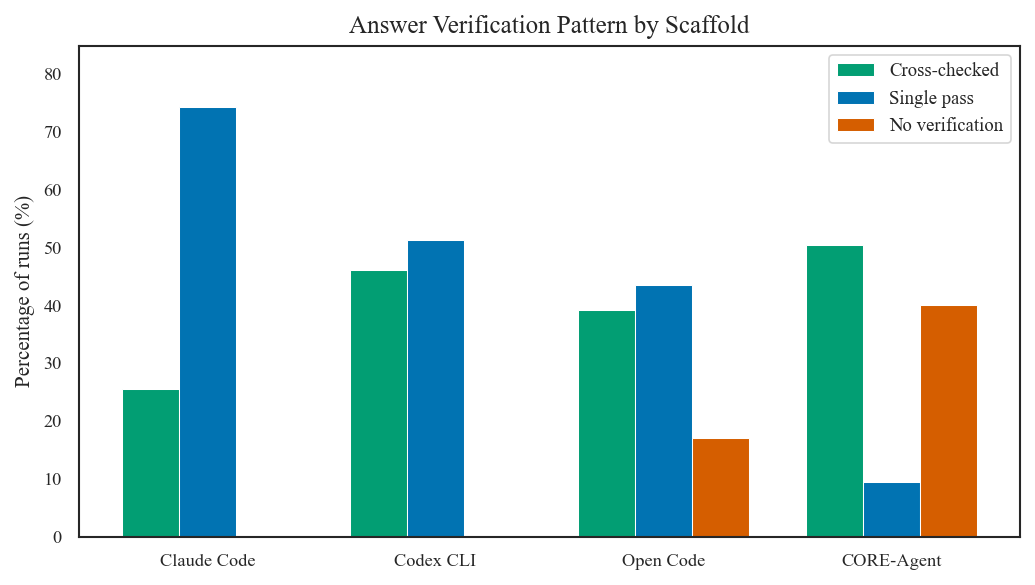

In [ ]:
rows = []
for r in rdata:
    if r.get("result_type") != "DIRECT_RESULT":
        continue
    out = r["output"]
    rows.append({
        "family": get_family(r["scaffold"]),
        "answer_verification": out["answer_verification"],
    })
rdf = pd.DataFrame(rows)

verif_order = ["cross_checked", "single_pass", "no_verification"]
verif_labels = {
    "cross_checked": "Cross-checked",
    "single_pass": "Single pass",
    "no_verification": "No verification",
}
_cb = sns.color_palette("colorblind", 10)
verif_colors = {
    "cross_checked": _cb[2],
    "single_pass": _cb[0],
    "no_verification": _cb[3],
}

family_order = ["Claude Code", "Codex CLI", "Open Code", "CORE-Agent"]
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(family_order))
width = 0.25

for i, verif in enumerate(verif_order):
    counts = []
    for fam in family_order:
        sub = rdf[rdf["family"] == fam]
        total = len(sub)
        count = len(sub[sub["answer_verification"] == verif])
        counts.append(count / total * 100 if total > 0 else 0)
    ax.bar(
        x + (i - 1) * width, counts, width,
        label=verif_labels[verif], color=verif_colors[verif],
        edgecolor="white", linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(family_order)
ax.set_ylabel("Percentage of runs (%)")
ax.set_ylim(0, 85)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Answer Verification Pattern by Scaffold")
fig.tight_layout()
fig.savefig(FIG_DIR / "behavioral_verification.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "behavioral_verification.pdf", bbox_inches="tight")
plt.show()